# Situational Awareness Portfolio

**FINM 25000 — Undergraduate Markets Project**

The Situational Awareness portfolio is long memory, networking, and data-center
infrastructure and short application software. Equal sleeves keep the view
transparent but ignore differences in estimated risk and return. This notebook
preserves the mandate, builds one stabilized optimizer, and decides whether it
improves on equal sleeves after 2024.

**Mandate.** 400% gross, 0% net. Long weights are nonnegative and sum to +2;
short weights are nonpositive and sum to −2.

**Timing.** The most recent 756 daily returns at each estimate date. First
estimate at the December 31, 2024 close, re-estimated at every later month-end
through June 30, 2026, each vector held over the following month's daily
returns, and one final estimate on July 31, 2026 for the allocation decision. A
weight set at the close of date $t$ first earns the return on the next trading
day. Equal sleeves reset on the same dates. Financing costs, transaction costs,
taxes, and market impact are ignored.

**What is held.** The object held between rebalances is the *weight vector*: the
book is rebalanced back to it each day, so gross exposure stays at 400% and net
at 0% on every date, which is the exposure the mandate specifies. The
alternative — holding the *positions* and letting weights drift with their own
returns — does not preserve the mandate, and Section 5.1 shows numerically how
far it drifts here.

---

## Setup

In [1]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter, FuncFormatter
from scipy.optimize import minimize
from scipy.stats import spearmanr

DATA = Path("data/project_situational_awareness_20260731.xlsx")
RULE = "cap"          # the position-cap rule, declared in Section 2.1

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

In [2]:
# --- chart styling ---------------------------------------------------------
# One validated palette used everywhere. Categorical slots are assigned in fixed
# order and never cycled; the three light-surface slots below 3:1 contrast carry
# visible direct labels, which is the required relief.
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
BLUE, RED = "#2a78d6", "#e34948"          # diverging poles: ahead / behind
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#fcfcfb", "#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95", "#0d366b"]
)
DIV_BR = LinearSegmentedColormap.from_list(
    "div_br", ["#0d366b", "#2a78d6", "#9ec5f4", "#f0efec", "#f3a6a6", "#e34948", "#8f2222"]
)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "lines.linewidth": 2.0, "lines.solid_capstyle": "round",
    "legend.frameon": False, "figure.dpi": 110,
})


def style(ax, title=None, ylabel=None, pct=None):
    """Recessive grid and axes; y-axis in percent when asked."""
    if title:
        ax.set_title(title, loc="left", fontsize=12, fontweight="bold", pad=10)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
    if pct is not None:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=pct))
    return ax


def label_ends(ax, frame, gap_frac=0.055):
    """Direct-label each series at its right edge, stacked so labels never collide.

    Series pinned to the same value (several names sitting on the 50% cap, say)
    would otherwise print on top of each other, so each label after the first is
    pushed down by a fixed gap and the y-limits are widened to fit the stack.
    """
    lo, hi = ax.get_ylim()
    gap = (hi - lo) * gap_frac
    last = frame.iloc[-1].sort_values(ascending=False)

    # `last` is sorted high to low, so each label sits at its own value or one
    # gap below the label above it -- monotone, no search, no tie to spin on.
    placed = []
    for value in last:
        placed.append(value if not placed else min(value, placed[-1] - gap))

    ax.set_ylim(min(lo, min(placed) - gap), max(hi, max(placed) + gap))
    for name, y in zip(last.index, placed):
        ax.annotate(
            name, xy=(frame.index[-1], y), xytext=(8, 0),
            textcoords="offset points", xycoords="data",
            va="center", ha="left", fontsize=9, color=INK2,
            annotation_clip=False,
        )


def signed_millions(v, _=None):
    """Axis ticks like +$80m / $0 / -$20m, with no leading + on zero."""
    if abs(v) < 1e-9:
        return "$0"
    return f"{'+' if v > 0 else '-'}${abs(v)/1e6:,.0f}m"


def show(df, money=(), pct=(), dec=4, title=None):
    """Display a frame with dollar and percent columns formatted for reading."""
    out = df.copy()
    for c in money:
        if c in out:
            out[c] = out[c].map(lambda v: f"${v:,.0f}" if pd.notna(v) else "")
    for c in pct:
        if c in out:
            out[c] = out[c].map(lambda v: f"{v:,.2%}" if pd.notna(v) else "")
    for c in out.columns:
        if c not in money and c not in pct and pd.api.types.is_float_dtype(out[c]):
            out[c] = out[c].round(dec)
    if title:
        print(title)
    display(out)

## The analysis engine

Every calculation in this report is defined below, so the notebook is
self-contained: it imports nothing beyond NumPy, pandas, SciPy, and Matplotlib,
and each number in Sections 1-6 traces to one function here. The narrative
resumes at Section 1.

In [3]:
# --------------------------------------------------------------------------- ## --------------------------------------------------------------------------- #
# Constants fixed by the brief
# --------------------------------------------------------------------------- #

ANNUALIZATION = 252          # trading days per year
WINDOW = 756                 # estimation window, in daily returns
LONG_TARGET = 2.0            # long weights sum to +2
SHORT_TARGET = -2.0          # short weights sum to -2
GROSS_TARGET = 4.0           # implied gross exposure
NET_TARGET = 0.0             # implied net exposure
NAV0 = 100_000_000.0         # $100m NAV
POSITION_CAP = 0.50          # |w_i| <= 50% of NAV  (position-cap rule)
SHRINK_DIVISOR = 4.0         # off-diagonal covariance divisor (shrinkage rule)

FIRST_ESTIMATE = pd.Timestamp("2024-12-31")
LAST_ESTIMATE = pd.Timestamp("2026-07-31")
TEST_START = pd.Timestamp("2025-01-02")
TEST_END = pd.Timestamp("2026-07-31")
REVERSAL_START = pd.Timestamp("2026-07-24")
REVERSAL_END = pd.Timestamp("2026-07-29")

TOL = 1e-8                   # feasibility tolerance for mandate checks

In [4]:
# --------------------------------------------------------------------------- #
# Data loading
# --------------------------------------------------------------------------- #

@dataclass
class Panel:
    """The loaded workbook, normalised into the objects the analysis needs."""

    descriptions: pd.DataFrame
    indexes: pd.DataFrame
    returns: pd.DataFrame
    baseline: pd.DataFrame
    longs: list[str]
    shorts: list[str]
    factors: list[str]

    @property
    def stocks(self) -> list[str]:
        """The 12 portfolio names, longs first then shorts."""
        return self.longs + self.shorts

    @property
    def stock_returns(self) -> pd.DataFrame:
        return self.returns[self.stocks]

    @property
    def equal_sleeve(self) -> pd.Series:
        """Equal-sleeve weights: +1/3 on each long, -1/3 on each short."""
        w = pd.Series(0.0, index=self.stocks, dtype=float)
        w[self.longs] = LONG_TARGET / len(self.longs)
        w[self.shorts] = SHORT_TARGET / len(self.shorts)
        return w


def _norm(cols) -> dict:
    """Map lowercased/stripped column names back to the originals."""
    return {str(c).strip().lower(): c for c in cols}


def load_panel(path: str | Path) -> Panel:
    """Read the project workbook and return a normalised :class:`Panel`."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Workbook not found at {path}. Place "
            "'project_situational_awareness_20260731.xlsx' in the data/ folder."
        )

    descriptions = pd.read_excel(path, sheet_name="descriptions")
    descriptions.columns = [str(c).strip() for c in descriptions.columns]
    descriptions = descriptions.set_index("ticker")

    returns = pd.read_excel(
        path, sheet_name="total returns", index_col="Date", parse_dates=True
    )
    returns.index = pd.DatetimeIndex(returns.index).normalize()
    returns = returns.sort_index()

    try:
        indexes = pd.read_excel(
            path, sheet_name="total return indexes", index_col="Date", parse_dates=True
        )
        indexes.index = pd.DatetimeIndex(indexes.index).normalize()
        indexes = indexes.sort_index()
    except ValueError:                                  # sheet name mismatch
        indexes = pd.DataFrame(index=returns.index)

    baseline = pd.read_excel(path, sheet_name="baseline weights")
    baseline.columns = [str(c).strip() for c in baseline.columns]
    baseline = baseline.set_index("ticker")

    side_col = _norm(descriptions.columns).get("side")
    sides = descriptions[side_col].astype(str).str.strip().str.lower()

    longs = [t for t in descriptions.index if sides[t] == "long" and t in returns]
    shorts = [t for t in descriptions.index if sides[t] == "short" and t in returns]
    factors = [t for t in descriptions.index if sides[t] == "factor" and t in returns]

    if len(longs) != 6 or len(shorts) != 6:
        raise ValueError(
            f"Expected 6 longs and 6 shorts; found {len(longs)} and {len(shorts)}."
        )

    return Panel(descriptions, indexes, returns, baseline, longs, shorts, factors)

In [5]:
# --------------------------------------------------------------------------- #
# Risk and return metrics
# --------------------------------------------------------------------------- #

def summarize(returns: pd.DataFrame | pd.Series, periods: int = ANNUALIZATION) -> pd.DataFrame:
    """Annualized mean, volatility, and Sharpe ratio (zero risk-free rate)."""
    df = returns.to_frame() if isinstance(returns, pd.Series) else returns
    mean = df.mean() * periods
    vol = df.std(ddof=1) * np.sqrt(periods)
    out = pd.DataFrame(
        {
            "ann. mean": mean,
            "ann. volatility": vol,
            "Sharpe ratio": mean / vol,
        }
    )
    return out


def drawdown_path(returns: pd.Series) -> pd.Series:
    """Drawdown of the cumulative wealth path, as a negative fraction."""
    wealth = (1.0 + returns).cumprod()
    return wealth / wealth.cummax() - 1.0


def performance_table(returns: pd.Series, periods: int = ANNUALIZATION) -> pd.Series:
    """The full metric set the brief asks for in 5.1."""
    dd = drawdown_path(returns)
    trough = dd.idxmin()
    worst_day = returns.idxmin()
    ann_mean = returns.mean() * periods
    ann_vol = returns.std(ddof=1) * np.sqrt(periods)
    return pd.Series(
        {
            "cumulative return": (1.0 + returns).prod() - 1.0,
            "ann. mean": ann_mean,
            "ann. volatility": ann_vol,
            "Sharpe ratio": ann_mean / ann_vol,
            "max drawdown": dd.min(),
            "max drawdown date": trough,
            "worst day": returns.min(),
            "worst day date": worst_day,
        }
    )

In [6]:
# --------------------------------------------------------------------------- #
# Estimation inputs
# --------------------------------------------------------------------------- #

def estimation_window(returns: pd.DataFrame, asof: pd.Timestamp, window: int = WINDOW) -> pd.DataFrame:
    """The most recent `window` daily returns at or before `asof`."""
    hist = returns.loc[:asof]
    if len(hist) < window:
        raise ValueError(
            f"Only {len(hist)} returns available through {asof.date()}; need {window}."
        )
    return hist.iloc[-window:]


def shrink_covariance(cov: pd.DataFrame, divisor: float = SHRINK_DIVISOR) -> pd.DataFrame:
    """Keep every sample variance; divide every off-diagonal covariance by `divisor`."""
    shrunk = cov.to_numpy(dtype=float) / divisor
    np.fill_diagonal(shrunk, np.diag(cov.to_numpy(dtype=float)))
    return pd.DataFrame(shrunk, index=cov.index, columns=cov.columns)


def estimate_inputs(
    returns: pd.DataFrame,
    asof: pd.Timestamp,
    rule: str,
    window: int = WINDOW,
    periods: int = ANNUALIZATION,
) -> tuple[pd.Series, pd.DataFrame, pd.DataFrame]:
    """Annualized mean vector and covariance matrix used by the optimizer.

    Returns ``(mu, sigma, sample_window)``.  Under the shrinkage rule the
    off-diagonal entries of the sample covariance are divided by four; the
    sample mean is used unchanged under both rules.
    """
    sample = estimation_window(returns, asof, window)
    mu = sample.mean() * periods
    cov = sample.cov(ddof=1) * periods
    if rule == "shrinkage":
        cov = shrink_covariance(cov)
    elif rule != "cap":
        raise ValueError("rule must be 'cap' or 'shrinkage'")
    return mu, cov, sample

In [7]:
# --------------------------------------------------------------------------- #
# The optimizer
# --------------------------------------------------------------------------- #

def _neg_sharpe(w: np.ndarray, mu: np.ndarray, cov: np.ndarray) -> float:
    vol = np.sqrt(max(w @ cov @ w, 1e-18))
    return -(w @ mu) / vol


def _neg_sharpe_grad(w: np.ndarray, mu: np.ndarray, cov: np.ndarray) -> np.ndarray:
    var = max(w @ cov @ w, 1e-18)
    vol = np.sqrt(var)
    ret = w @ mu
    # d/dw [ -(w'mu) / sqrt(w'Sw) ]
    return -(mu / vol) + (ret / vol**3) * (cov @ w)


@dataclass
class OptResult:
    weights: pd.Series
    success: bool
    message: str
    n_iter: int
    objective: float          # attained Sharpe ratio
    rule: str
    asof: pd.Timestamp


def optimize_weights(
    mu: pd.Series,
    cov: pd.DataFrame,
    longs: list[str],
    shorts: list[str],
    rule: str,
    x0: pd.Series | None = None,
    asof: pd.Timestamp | None = None,
) -> OptResult:
    """Maximize the estimated Sharpe ratio subject to the mandate.

        maximize    w'mu / sqrt(w' Sigma w)          (risk-free rate = 0)
        subject to  sum(w_long)  = +2,  w_long  >= 0
                    sum(w_short) = -2,  w_short <= 0
                    |w_i| <= 0.50                    (position-cap rule only)

    The two sleeve equalities imply 400% gross and 0% net exposure.
    """
    names = list(mu.index)
    mu_v = mu.to_numpy(dtype=float)
    cov_v = cov.loc[names, names].to_numpy(dtype=float)
    long_mask = np.array([n in set(longs) for n in names])
    short_mask = np.array([n in set(shorts) for n in names])

    if rule == "cap":
        bounds = [
            (0.0, POSITION_CAP) if lm else (-POSITION_CAP, 0.0)
            for lm in long_mask
        ]
    else:                                            # shrinkage: no position cap
        bounds = [
            (0.0, LONG_TARGET) if lm else (SHORT_TARGET, 0.0)
            for lm in long_mask
        ]

    constraints = [
        {
            "type": "eq",
            "fun": lambda w, m=long_mask: w[m].sum() - LONG_TARGET,
            "jac": lambda w, m=long_mask: m.astype(float),
        },
        {
            "type": "eq",
            "fun": lambda w, m=short_mask: w[m].sum() - SHORT_TARGET,
            "jac": lambda w, m=short_mask: m.astype(float),
        },
    ]

    if x0 is None:
        x0 = pd.Series(0.0, index=names)
        x0[long_mask] = LONG_TARGET / long_mask.sum()
        x0[short_mask] = SHORT_TARGET / short_mask.sum()
    start = np.clip(
        x0.reindex(names).to_numpy(dtype=float),
        [b[0] for b in bounds],
        [b[1] for b in bounds],
    )

    res = minimize(
        _neg_sharpe,
        start,
        args=(mu_v, cov_v),
        jac=_neg_sharpe_grad,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-12},
    )

    w = pd.Series(res.x, index=names)
    # Clean numerical dust so the sign constraints hold exactly.
    w[long_mask] = w[long_mask].clip(lower=0.0)
    w[short_mask] = w[short_mask].clip(upper=0.0)
    w[long_mask] *= LONG_TARGET / w[long_mask].sum()
    w[short_mask] *= SHORT_TARGET / w[short_mask].sum()
    w += 0.0                                     # -0.0 -> 0.0 for cleared positions

    return OptResult(
        weights=w,
        success=bool(res.success),
        message=str(res.message),
        n_iter=int(res.nit),
        objective=float(-_neg_sharpe(w.to_numpy(), mu_v, cov_v)),
        rule=rule,
        asof=asof,
    )


def multistart_check(
    mu: pd.Series,
    cov: pd.DataFrame,
    longs: list[str],
    shorts: list[str],
    rule: str,
    n_starts: int = 200,
    seed: int = 25000,
) -> tuple[float, pd.Series]:
    """Random restarts, used only to confirm the mandated start is not a poor local max.

    Returns the best attained Sharpe ratio and the weights that achieved it.
    """
    rng = np.random.default_rng(seed)
    names = list(mu.index)
    best_obj, best_w = -np.inf, None
    cap = POSITION_CAP if rule == "cap" else LONG_TARGET

    for _ in range(n_starts):
        x0 = pd.Series(0.0, index=names, dtype=float)
        for sleeve, target in ((longs, LONG_TARGET), (shorts, SHORT_TARGET)):
            raw = rng.dirichlet(np.ones(len(sleeve)))
            # Reject draws that cannot be scaled inside the box.
            for _ in range(50):
                if raw.max() * abs(target) <= cap:
                    break
                raw = rng.dirichlet(np.ones(len(sleeve)) * 5.0)
            x0[sleeve] = raw * target
        res = optimize_weights(mu, cov, longs, shorts, rule, x0=x0)
        if res.success and res.objective > best_obj:
            best_obj, best_w = res.objective, res.weights

    return best_obj, best_w

In [8]:
# --------------------------------------------------------------------------- #
# Mandate verification
# --------------------------------------------------------------------------- #

def mandate_checks(w: pd.Series, longs: list[str], shorts: list[str], rule: str) -> pd.Series:
    """Every constraint in the mandate, as a labelled pass/fail row."""
    wl, ws = w[longs], w[shorts]
    checks = {
        "long sum = +2": abs(wl.sum() - LONG_TARGET) < TOL,
        "short sum = -2": abs(ws.sum() - SHORT_TARGET) < TOL,
        "gross = 400%": abs(w.abs().sum() - GROSS_TARGET) < TOL,
        "net = 0%": abs(w.sum() - NET_TARGET) < TOL,
        "longs nonnegative": bool((wl >= -TOL).all()),
        "shorts nonpositive": bool((ws <= TOL).all()),
    }
    if rule == "cap":
        checks["|w| <= 50% cap"] = bool((w.abs() <= POSITION_CAP + TOL).all())
    return pd.Series(checks)


def exposure_summary(w: pd.Series, longs: list[str], shorts: list[str]) -> pd.Series:
    """Long, short, gross, and net exposure plus the largest absolute position."""
    return pd.Series(
        {
            "long exposure": w[longs].sum(),
            "short exposure": w[shorts].sum(),
            "gross exposure": w.abs().sum(),
            "net exposure": w.sum(),
            "largest |position|": w.abs().max(),
            "largest position name": w.abs().idxmax(),
        }
    )

In [9]:
# --------------------------------------------------------------------------- #
# Rolling estimation and the backtest
# --------------------------------------------------------------------------- #

def month_end_dates(
    returns: pd.DataFrame,
    first: pd.Timestamp = FIRST_ESTIMATE,
    last: pd.Timestamp = LAST_ESTIMATE,
) -> list[pd.Timestamp]:
    """Trading month-ends in the index, from `first` through `last` inclusive."""
    idx = returns.loc[first:last].index
    ends = pd.Series(idx, index=idx).groupby([idx.year, idx.month]).max()
    dates = sorted(pd.DatetimeIndex(ends.to_numpy()))
    if dates and dates[0] != first:
        dates = [first] + [d for d in dates if d > first]
    return dates


def rolling_weights(
    panel: Panel, rule: str, dates: list[pd.Timestamp] | None = None
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """Optimize at every estimate date.

    Returns ``(weights, diagnostics, inputs)`` where `weights` is indexed by
    estimate date, `diagnostics` records solver status and mandate checks, and
    `inputs` maps each date to its ``(mu, sigma)`` estimates.
    """
    dates = dates or month_end_dates(panel.returns)
    rets = panel.stock_returns
    start = panel.equal_sleeve

    rows, diag, inputs = {}, {}, {}
    for d in dates:
        mu, cov, _ = estimate_inputs(rets, d, rule)
        res = optimize_weights(mu, cov, panel.longs, panel.shorts, rule, x0=start, asof=d)
        checks = mandate_checks(res.weights, panel.longs, panel.shorts, rule)
        rows[d] = res.weights
        inputs[d] = (mu, cov)
        diag[d] = pd.Series(
            {
                "solver success": res.success,
                "iterations": res.n_iter,
                "est. Sharpe": res.objective,
                "max |w|": res.weights.abs().max(),
                "all checks pass": bool(checks.all()),
                "message": res.message,
            }
        )

    weights = pd.DataFrame(rows).T[panel.stocks]
    weights.index.name = "estimate date"
    diagnostics = pd.DataFrame(diag).T
    diagnostics.index.name = "estimate date"
    return weights, diagnostics, inputs


def backtest(
    panel: Panel,
    targets: pd.DataFrame,
    start: pd.Timestamp = TEST_START,
    end: pd.Timestamp = TEST_END,
    nav0: float = NAV0,
    drift: bool = False,
) -> dict:
    """Hold each weight vector over the following month's daily returns.

    Weights set at the close of an estimate date first earn the next trading
    day's return.

    With ``drift=False`` (the default) the *weight vector* is what is held: the
    book is rebalanced back to it each day, so gross stays at 400% and net at 0%
    on every date, which is the exposure the mandate specifies.  With
    ``drift=True`` the *positions* are held instead and weights drift with their
    own returns, which lets gross exposure wander away from 400% between
    rebalances.  See the notebook's Section 5.1 aside for what that does here.

    Returns a dict with the daily return series, NAV path, held weights, daily
    per-stock contributions, and the trade list at each rebalance.
    """
    rets = panel.stock_returns.loc[start:end]
    rebal_dates = [d for d in targets.index if d <= end]

    nav = nav0
    port_ret, nav_path, held, contrib, trades = {}, {}, {}, {}, {}

    # Weights in force on the first test day come from the last estimate on or
    # before the day preceding `start`.
    prior = [d for d in rebal_dates if d < start]
    w = targets.loc[prior[-1]].copy() if prior else targets.iloc[0].copy()

    for t in rets.index:
        # Rebalance at the close of an estimate date, before the next day's return.
        r = rets.loc[t]
        held[t] = w.copy()
        pnl_i = w * r                                    # contribution to today's return
        r_p = float(pnl_i.sum())

        contrib[t] = pnl_i * nav                         # dollar P&L per stock
        nav_new = nav * (1.0 + r_p)
        port_ret[t] = r_p
        nav_path[t] = nav_new

        if drift:                                        # hold positions, not weights
            w = w * (1.0 + r) / (1.0 + r_p)
        nav = nav_new

        if t in targets.index:                           # month-end: reset to target
            target = targets.loc[t]
            trades[t] = target - w
            w = target.copy()

    return {
        "returns": pd.Series(port_ret).sort_index(),
        "nav": pd.Series(nav_path).sort_index(),
        "held_weights": pd.DataFrame(held).T[panel.stocks],
        "contributions": pd.DataFrame(contrib).T[panel.stocks],
        "trades": pd.DataFrame(trades).T[panel.stocks] if trades else pd.DataFrame(),
    }


def equal_sleeve_targets(panel: Panel, dates: list[pd.Timestamp] | None = None) -> pd.DataFrame:
    """Equal-sleeve weights reset on the same month-end dates."""
    dates = dates or month_end_dates(panel.returns)
    w = panel.equal_sleeve
    out = pd.DataFrame({d: w for d in dates}).T[panel.stocks]
    out.index.name = "estimate date"
    return out


def turnover(
    result: dict,
    periods_per_year: float = ANNUALIZATION,
    exclude: list[pd.Timestamp] | None = None,
) -> dict:
    """Annualized one-way turnover.

    One-way turnover at a rebalance is ``0.5 * sum |w_target - w_drifted|`` —
    the fraction of NAV actually traded.  Annualizing divides the total traded
    over the test window by the length of that window in years.

    `exclude` drops rebalance dates that are not trades inside the test window;
    the July 31, 2026 estimate is the final allocation decision, never held, so
    it is excluded from the turnover the backtest actually incurred.
    """
    trades = result["trades"]
    if exclude:
        trades = trades.drop(index=[d for d in exclude if d in trades.index])
    if trades.empty:
        return {"per rebalance": pd.Series(dtype=float), "annualized one-way": 0.0}
    per_rebal = 0.5 * trades.abs().sum(axis=1)
    years = len(result["returns"]) / periods_per_year
    return {
        "per rebalance": per_rebal,
        "n rebalances": int(len(per_rebal)),
        "total one-way": float(per_rebal.sum()),
        "annualized one-way": float(per_rebal.sum() / years),
        "years": years,
    }

In [10]:
# --------------------------------------------------------------------------- #
# Diagnostics used in the write-up
# --------------------------------------------------------------------------- #

def estimated_performance(w: pd.Series, mu: pd.Series, cov: pd.DataFrame) -> pd.Series:
    """Annualized mean, volatility, and Sharpe implied by the estimates."""
    names = list(mu.index)
    wv = w.reindex(names).to_numpy(dtype=float)
    mean = float(wv @ mu.to_numpy(dtype=float))
    vol = float(np.sqrt(wv @ cov.loc[names, names].to_numpy(dtype=float) @ wv))
    return pd.Series(
        {"ann. mean": mean, "ann. volatility": vol, "Sharpe ratio": mean / vol}
    )


def unconstrained_tangency(mu: pd.Series, cov: pd.DataFrame, gross: float = GROSS_TARGET) -> pd.Series:
    """Textbook tangency weights, rescaled to the mandate's gross exposure.

    Shown only to demonstrate what the mandate's constraints are protecting
    against: with no sign, sleeve, or size restrictions the solution is
    ``Sigma^-1 mu``, which inverts a near-singular matrix.
    """
    names = list(mu.index)
    raw = np.linalg.solve(cov.loc[names, names].to_numpy(dtype=float), mu.to_numpy(dtype=float))
    w = pd.Series(raw, index=names)
    return w * gross / w.abs().sum()


def collinearity_diagnostics(sample: pd.DataFrame, longs: list[str], shorts: list[str]) -> pd.Series:
    """How close the estimated correlation matrix is to singular."""
    corr = sample.corr()
    eig = np.linalg.eigvalsh(corr.to_numpy(dtype=float))
    off = corr.where(~np.eye(len(corr), dtype=bool))

    def _avg(block: pd.DataFrame) -> float:
        vals = block.to_numpy(dtype=float)
        mask = ~np.eye(len(block), dtype=bool) if block.shape[0] == block.shape[1] else np.ones_like(vals, bool)
        return float(np.nanmean(vals[mask]))

    return pd.Series(
        {
            "mean pairwise correlation": float(off.stack().mean()),
            "max pairwise correlation": float(off.stack().max()),
            "mean corr. within long sleeve": _avg(corr.loc[longs, longs]),
            "mean corr. within short sleeve": _avg(corr.loc[shorts, shorts]),
            "mean corr. across sleeves": _avg(corr.loc[longs, shorts]),
            "largest eigenvalue": float(eig[-1]),
            "smallest eigenvalue": float(eig[0]),
            "condition number": float(eig[-1] / eig[0]),
        }
    )


def sleeve_diagnostics(
    mu: pd.Series, cov: pd.DataFrame, w: pd.Series, longs: list[str], shorts: list[str]
) -> pd.DataFrame:
    """Per-stock estimates plus the quantities that drive the optimizer's tilts.

    ``avg corr. in sleeve`` measures how redundant a name is with its own
    sleeve; a name that is both high-Sharpe and low-correlation with its
    sleeve-mates is what the optimizer buys.
    """
    names = list(mu.index)
    vol = pd.Series(np.sqrt(np.diag(cov.loc[names, names].to_numpy(dtype=float))), index=names)
    corr = cov.loc[names, names].div(vol, axis=0).div(vol, axis=1)

    avg_in_sleeve = {}
    for sleeve in (longs, shorts):
        block = corr.loc[sleeve, sleeve]
        for n in sleeve:
            avg_in_sleeve[n] = float(block.loc[n].drop(n).mean())

    wv = w.reindex(names).to_numpy(dtype=float)
    cov_v = cov.loc[names, names].to_numpy(dtype=float)
    port_vol = float(np.sqrt(wv @ cov_v @ wv))
    mctr = pd.Series((cov_v @ wv) / port_vol, index=names)   # marginal contribution to risk

    return pd.DataFrame(
        {
            "ann. mean": mu.reindex(names),
            "ann. volatility": vol,
            "Sharpe ratio": mu.reindex(names) / vol,
            "avg corr. in sleeve": pd.Series(avg_in_sleeve).reindex(names),
            "marg. contrib. to risk": mctr,
            "contrib. to risk": mctr * pd.Series(wv, index=names),
        }
    )


def window_attribution(
    result: dict, start: pd.Timestamp, end: pd.Timestamp, longs: list[str], shorts: list[str]
) -> dict:
    """Return and dollar P&L over a window, split by sleeve and by stock.

    Dollar contributions are exactly additive: each day's per-stock P&L is
    ``w_i * r_i * NAV_{t-1}``, and those dollars sum to the window's total P&L.
    """
    rets = result["returns"].loc[start:end]
    nav = result["nav"]
    contrib = result["contributions"].loc[start:end]

    prior_nav = nav.shift(1)
    nav_start = float(prior_nav.loc[rets.index[0]]) if not np.isnan(prior_nav.loc[rets.index[0]]) else NAV0
    nav_end = float(nav.loc[rets.index[-1]])

    by_stock = contrib.sum()
    return {
        "dates": rets.index,
        "return": float((1.0 + rets).prod() - 1.0),
        "pnl": nav_end - nav_start,
        "nav start": nav_start,
        "nav end": nav_end,
        "by stock": by_stock,
        "long sleeve pnl": float(by_stock[longs].sum()),
        "short sleeve pnl": float(by_stock[shorts].sum()),
        "daily returns": rets,
    }

### Load the panel

In [11]:
panel = load_panel(DATA)
rets = panel.stock_returns          # the 12 mandate names, longs then shorts

print(f"tickers in file        : {panel.returns.shape[1]}  "
      f"({len(panel.longs)} long, {len(panel.shorts)} short, {len(panel.factors)} factor)")
print(f"daily returns          : {len(panel.returns):,}")
print(f"sample                 : {panel.returns.index[0]:%Y-%m-%d} to {panel.returns.index[-1]:%Y-%m-%d}")
print(f"missing values         : {int(panel.returns.isna().sum().sum())}")
print(f"returns through 2024-12-31 : {len(rets.loc[:FIRST_ESTIMATE]):,} "
      f"(estimation window uses the last {WINDOW})")

display(panel.descriptions)

tickers in file        : 15  (6 long, 6 short, 3 factor)
daily returns          : 1,400
sample                 : 2021-01-04 to 2026-07-31
missing values         : 0
returns through 2024-12-31 : 1,005 (estimation window uses the last 756)


,name,theme,side
ticker,,,
SNDK,Sandisk,memory and storage,long
MU,Micron Technology,memory,long
VRT,Vertiv,data-center power and cooling,long
LITE,Lumentum,optical networking,long
COHR,Coherent,optical networking,long
BE,Bloom Energy,data-center power,long
ADBE,Adobe,application software,short
CRM,Salesforce,application software,short
ORCL,Oracle,enterprise software,short


The workbook ships a `checks` sheet and a `total return indexes` sheet. Both are
used below as an integrity test: the daily returns should be the percent change
of the total-return indexes to machine precision.

In [12]:
try:
    checks_sheet = pd.read_excel(DATA, sheet_name="checks")
    display(checks_sheet)
except ValueError as exc:
    print(f"no 'checks' sheet readable: {exc}")

if not panel.indexes.empty:
    common_cols = [c for c in panel.stocks if c in panel.indexes.columns]
    implied = panel.indexes[common_cols].pct_change()
    common_idx = implied.index.intersection(rets.index)
    err = (implied.loc[common_idx, common_cols] - rets.loc[common_idx, common_cols]).abs().max().max()
    print(f"\nmax |stated return - index pct-change| across the panel: {err:.3e}")
    print("returns reconcile to the total-return indexes:", bool(err < 1e-8))

,check,actual,expected,difference,tolerance,status,notes
0,long sleeve exposure,2.0000,2,-0.0000,0.0000,PASS,Sum of the six long weights.
1,short sleeve exposure,-2.0000,-2,0.0000,0.0000,PASS,Sum of the six short weights.
2,gross exposure,4.0000,4,-0.0000,0.0000,PASS,Long exposure minus short exposure.
3,net exposure,0,0,0.0000,0.0000,PASS,Sum of all 12 stock weights.
4,return observations,1400,1400,0.0000,0.0000,PASS,All 15 output series share these dates.
5,last date,2026-07-31,2026-07-31,NaN,0.0000,PASS,Pinned assessment date.



max |stated return - index pct-change| across the panel: 0.000e+00
returns reconcile to the total-return indexes: True


---
# 1 The Mandate

## 1.1 Equal-sleeve exposures and positions

In [13]:
w_eq = panel.equal_sleeve

positions = pd.DataFrame({
    "name": panel.descriptions["name"].reindex(panel.stocks),
    "theme": panel.descriptions["theme"].reindex(panel.stocks),
    "side": panel.descriptions["side"].reindex(panel.stocks),
    "equal-sleeve weight": w_eq,
    "position on $100m NAV": w_eq * NAV0,
})
show(positions, money=["position on $100m NAV"], dec=6,
     title="Equal-sleeve positions")

Equal-sleeve positions


,name,theme,side,equal-sleeve weight,position on $100m NAV
SNDK,Sandisk,memory and storage,long,0.3333,"$33,333,333"
MU,Micron Technology,memory,long,0.3333,"$33,333,333"
VRT,Vertiv,data-center power and cooling,long,0.3333,"$33,333,333"
LITE,Lumentum,optical networking,long,0.3333,"$33,333,333"
COHR,Coherent,optical networking,long,0.3333,"$33,333,333"
BE,Bloom Energy,data-center power,long,0.3333,"$33,333,333"
ADBE,Adobe,application software,short,-0.3333,"$-33,333,333"
CRM,Salesforce,application software,short,-0.3333,"$-33,333,333"
ORCL,Oracle,enterprise software,short,-0.3333,"$-33,333,333"
NOW,ServiceNow,enterprise software,short,-0.3333,"$-33,333,333"


In [14]:
exp_eq = exposure_summary(w_eq, panel.longs, panel.shorts)
chk_eq = mandate_checks(w_eq, panel.longs, panel.shorts, RULE)

print("Exposures")
display(exp_eq.to_frame("equal sleeve"))
print("\nMandate checks")
display(chk_eq.to_frame("pass"))
print("\nall mandate checks pass:", bool(chk_eq.all()))

# Cross-check against the workbook's own baseline-weights sheet.
wcol = [c for c in panel.baseline.columns if "weight" in str(c).lower()][0]
w_book = panel.baseline[wcol].reindex(panel.stocks).astype(float)
print("constructed weights match the workbook's baseline sheet:",
      bool(np.allclose(w_book.to_numpy(), w_eq.to_numpy(), atol=1e-12)))
print(f"gross on $100m NAV : ${w_eq.abs().sum() * NAV0:,.0f}")
print(f"net   on $100m NAV : ${w_eq.sum() * NAV0:,.0f}")

Exposures


,equal sleeve
long exposure,2.0000
short exposure,-2.0000
gross exposure,4.0000
net exposure,0.0000
largest |position|,0.3333
largest position name,SNDK



Mandate checks


,pass
long sum = +2,True
short sum = -2,True
gross = 400%,True
net = 0%,True
longs nonnegative,True
shorts nonpositive,True
|w| <= 50% cap,True



all mandate checks pass: True
constructed weights match the workbook's baseline sheet: True
gross on $100m NAV : $400,000,000
net   on $100m NAV : $0


The equal-sleeve portfolio *is* the mandate, with nothing left over. Each of the
six longs carries +1/3 of NAV and each of the six shorts −1/3, so the long sleeve
sums to +200%, the short sleeve to −200%, gross exposure is 400% and net exposure
is 0%.

On $100 million of NAV that is **$33,333,333 long in each of SNDK, MU, VRT, LITE,
COHR, and BE**, and **$33,333,333 short in each of ADBE, CRM, ORCL, NOW, WDAY, and
MDB** — $400 million of gross exposure carried against zero net.

Two checks worth recording. The weights constructed here match the workbook's own
`baseline weights` sheet to machine precision, and the workbook's `checks` sheet
independently confirms the same four exposures. And the largest absolute position,
33.33% of NAV, sits well inside the 50% cap the optimizer will face in Section 2 —
so equal sleeves is itself a feasible point of that optimization problem, which is
what allows it to serve as the starting vector.

## 1.2 Estimates available through December 31, 2024

In [15]:
ASOF = FIRST_ESTIMATE
mu24, cov24, sample24 = estimate_inputs(rets, ASOF, RULE)   # RULE="cap" -> plain sample covariance

print(f"estimation window: {sample24.index[0]:%Y-%m-%d} to {sample24.index[-1]:%Y-%m-%d} "
      f"({len(sample24)} daily returns)")

stats = summarize(sample24)
stats_full = summarize(rets.loc[:ASOF])
stats.insert(0, "side", panel.descriptions["side"].reindex(stats.index))
stats["ann. mean (full)"] = stats_full["ann. mean"]
stats["Sharpe (full)"] = stats_full["Sharpe ratio"]
stats = stats.loc[panel.stocks]

show(stats,
     pct=["ann. mean", "ann. volatility", "ann. mean (full)"],
     title=f"Annualized estimates over the {WINDOW}-day window ending {ASOF:%Y-%m-%d}, "
           f"with the full available sample for comparison")

estimation window: 2021-12-29 to 2024-12-31 (756 daily returns)
Annualized estimates over the 756-day window ending 2024-12-31, with the full available sample for comparison


,side,ann. mean,ann. volatility,Sharpe ratio,ann. mean (full),Sharpe (full)
SNDK,long,6.94%,41.78%,0.1660,10.63%,0.2532
MU,long,7.70%,45.55%,0.1691,13.10%,0.2966
VRT,long,71.18%,62.84%,1.1328,61.66%,1.0923
LITE,long,3.84%,48.02%,0.0800,7.55%,0.1654
COHR,long,26.98%,56.36%,0.4788,19.93%,0.3732
BE,long,30.69%,79.28%,0.3871,23.58%,0.2963
ADBE,short,-0.84%,38.21%,-0.0219,3.71%,0.1025
CRM,short,16.55%,38.31%,0.4320,16.91%,0.4687
ORCL,short,27.30%,30.95%,0.8822,29.87%,0.9773
NOW,short,24.83%,41.82%,0.5937,24.58%,0.6088


In [16]:
corr24 = sample24.corr().loc[panel.stocks, panel.stocks]
display(corr24.round(2))          # table view of the heatmap below

,SNDK,MU,VRT,LITE,COHR,BE,ADBE,CRM,ORCL,NOW,WDAY,MDB
SNDK,1.0000,0.7200,0.4400,0.4700,0.4900,0.3200,0.4100,0.3800,0.3400,0.3500,0.3000,0.3600
MU,0.7200,1.0000,0.4300,0.4700,0.5000,0.3100,0.4100,0.4000,0.3700,0.3800,0.3600,0.3600
VRT,0.4400,0.4300,1.0000,0.4100,0.4500,0.3000,0.3800,0.4000,0.3900,0.4200,0.3200,0.4000
LITE,0.4700,0.4700,0.4100,1.0000,0.6500,0.3100,0.3500,0.4000,0.3400,0.3700,0.3500,0.3300
COHR,0.4900,0.5000,0.4500,0.6500,1.0000,0.2900,0.3600,0.3600,0.3600,0.3800,0.3400,0.3600
BE,0.3200,0.3100,0.3000,0.3100,0.2900,1.0000,0.2500,0.2800,0.2300,0.3000,0.2800,0.3300
ADBE,0.4100,0.4100,0.3800,0.3500,0.3600,0.2500,1.0000,0.6100,0.4500,0.6500,0.5600,0.5100
CRM,0.3800,0.4000,0.4000,0.4000,0.3600,0.2800,0.6100,1.0000,0.4100,0.7100,0.6200,0.5000
ORCL,0.3400,0.3700,0.3900,0.3400,0.3600,0.2300,0.4500,0.4100,1.0000,0.4700,0.3700,0.3500
NOW,0.3500,0.3800,0.4200,0.3700,0.3800,0.3000,0.6500,0.7100,0.4700,1.0000,0.6400,0.6300


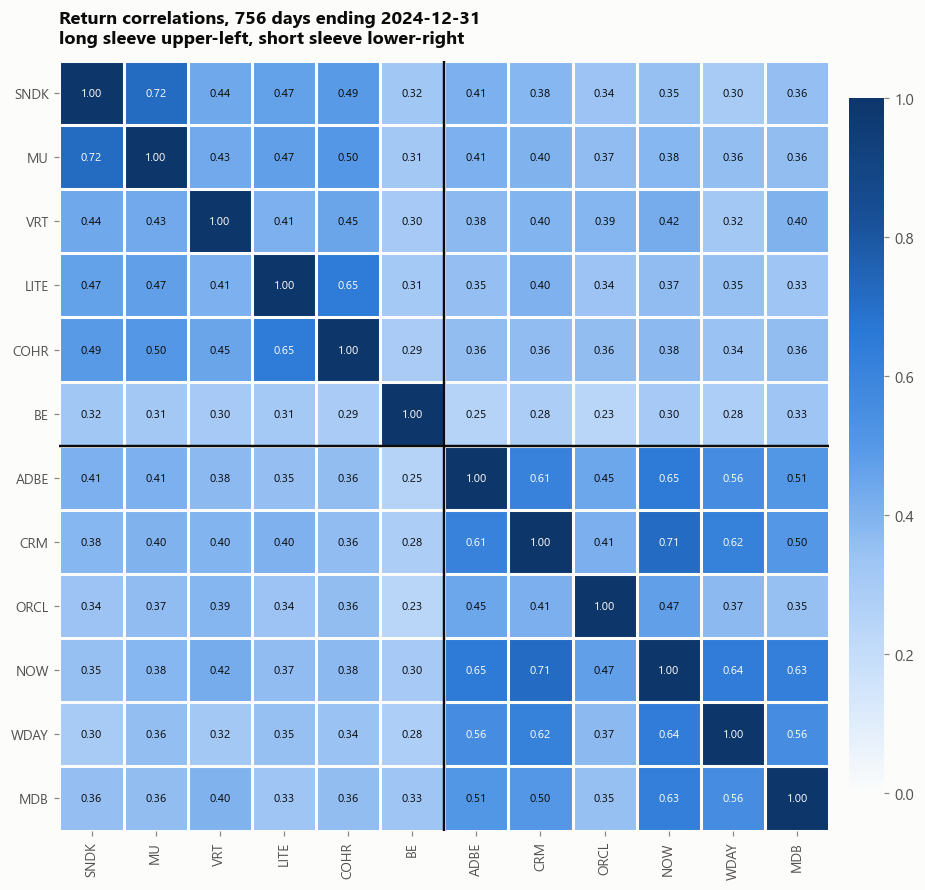

In [17]:
fig, ax = plt.subplots(figsize=(9.6, 8.2))

vals = corr24.to_numpy()
off = vals[~np.eye(len(vals), dtype=bool)]
if off.min() >= 0:                      # magnitude only -> one hue, light to dark
    cmap, vmin, vmax = SEQ_BLUE, 0.0, 1.0
else:                                   # polarity -> two hues with a neutral midpoint
    cmap, vmin, vmax = DIV_BR, -1.0, 1.0

im = ax.imshow(vals, cmap=cmap, vmin=vmin, vmax=vmax)

n = len(corr24)
ax.set_xticks(range(n), corr24.columns, rotation=90, fontsize=9)
ax.set_yticks(range(n), corr24.index, fontsize=9)
ax.set_xticks(np.arange(-.5, n, 1), minor=True)
ax.set_yticks(np.arange(-.5, n, 1), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)   # 2px surface gap between cells
ax.grid(which="major", visible=False)
ax.tick_params(which="minor", length=0)
for s in ax.spines.values():
    s.set_visible(False)

norm = im.norm
for i in range(n):
    for j in range(n):
        v = vals[i, j]
        dark = norm(v) > 0.55
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color=SURFACE if dark else INK)

# Sleeve boundary: the first 6 names are the long sleeve.
b = len(panel.longs) - 0.5
for pos in (b,):
    ax.axhline(pos, color=INK, lw=1.6)
    ax.axvline(pos, color=INK, lw=1.6)

ax.set_title(f"Return correlations, {WINDOW} days ending {ASOF:%Y-%m-%d}\n"
             f"long sleeve upper-left, short sleeve lower-right",
             loc="left", fontsize=12, fontweight="bold", pad=12)
cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cb.outline.set_visible(False)
cb.ax.tick_params(colors=MUTED, labelcolor=INK2)
plt.tight_layout()
plt.show()

The two diagnostics below say what the correlation matrix does to an optimizer.
`condition number` is the ratio of the largest to the smallest eigenvalue of the
correlation matrix — the amplification factor applied to estimation error when
the matrix is inverted. The second cell shows the textbook unconstrained
tangency solution $w \propto \Sigma^{-1}\mu$ rescaled to the mandate's 400%
gross, which is what the sleeve, sign, and size constraints exist to prevent.

In [18]:
diag_collin = collinearity_diagnostics(sample24, panel.longs, panel.shorts)
display(diag_collin.to_frame("value"))

,value
mean pairwise correlation,0.4139
max pairwise correlation,0.7185
mean corr. within long sleeve,0.4379
mean corr. within short sleeve,0.5356
mean corr. across sleeves,0.3495
largest eigenvalue,5.6085
smallest eigenvalue,0.2461
condition number,22.7895


In [19]:
w_unc = unconstrained_tangency(mu24, cov24)
unc = pd.DataFrame({
    "side": panel.descriptions["side"].reindex(panel.stocks),
    "equal sleeve": w_eq,
    "unconstrained tangency": w_unc.reindex(panel.stocks),
    "position on $100m NAV": w_unc.reindex(panel.stocks) * NAV0,
})
show(unc, money=["position on $100m NAV"], title="Unconstrained tangency at 400% gross")

wrong_side = sum(
    (w_unc[t] < 0 if t in panel.longs else w_unc[t] > 0) for t in panel.stocks
)
print(f"largest |position|            : {w_unc.abs().max():.1%} of NAV ({w_unc.abs().idxmax()})")
print(f"net exposure                  : {w_unc.sum():+.1%} of NAV  (mandate requires 0%)")
print(f"names on the wrong side       : {wrong_side} of {len(panel.stocks)}")
print(f"estimated Sharpe (in sample)  : "
      f"{estimated_performance(w_unc, mu24, cov24)['Sharpe ratio']:.2f}")

Unconstrained tangency at 400% gross


,side,equal sleeve,unconstrained tangency,position on $100m NAV
SNDK,long,0.3333,-0.1043,"$-10,427,835"
MU,long,0.3333,-0.1578,"$-15,777,459"
VRT,long,0.3333,0.5567,"$55,670,248"
LITE,long,0.3333,-0.3624,"$-36,236,133"
COHR,long,0.3333,0.2124,"$21,240,199"
BE,long,0.3333,0.0812,"$8,119,463"
ADBE,short,-0.3333,-0.6309,"$-63,088,385"
CRM,short,-0.3333,0.1664,"$16,636,655"
ORCL,short,-0.3333,0.7035,"$70,347,149"
NOW,short,-0.3333,0.5818,"$58,181,412"


largest |position|            : 70.3% of NAV (ORCL)
net exposure                  : +60.4% of NAV  (mandate requires 0%)
names on the wrong side       : 6 of 12
estimated Sharpe (in sample)  : 1.71


Estimated on the 756 days ending December 31, 2024, the twelve names look very
unlike each other. Annualized means run from −3.17% (MDB) to +71.18% (VRT);
volatilities from 30.95% (ORCL) to 79.28% (BE); Sharpe ratios from −0.0448 (MDB)
to 1.1328 (VRT). Those spreads are what an optimizer trades on.

### The feature that would make an unconstrained optimizer unreliable

**The sleeves are internally near-collinear, while the estimated means inside each
sleeve disagree far more than the data can support.**

The short sleeve shows it most clearly. Its six names average a 0.5356 pairwise
correlation — NOW with CRM at 0.71, NOW with ADBE at 0.65, NOW with WDAY at 0.64 —
so as risk exposures they are close to the same asset. Yet their estimated annual
means run from −3.17% to +27.30%, a 30-point spread. With 756 daily returns, three
years of data, the standard error on an annualized mean is roughly the annualized
volatility divided by $\sqrt{3}$: for names near 38% volatility that is about 22
points. The entire cross-sleeve disagreement the optimizer is being asked to act on
is comparable to one standard error of a single estimate.

That combination — assets that are nearly the same, with mean estimates that are
nearly noise — is what breaks mean-variance optimization. The correlation matrix
has a largest eigenvalue of 5.61 against a smallest of 0.2461, a condition number
of **22.8**. The direction associated with that smallest eigenvalue is a long-short
combination *within* a sleeve that the sample says carries almost no variance.
Inverting $\Sigma$ amplifies whatever mean difference happens to sit along that
direction by the reciprocal of a very small number, and the resulting position is
limited only by how small the variance estimate is — not by any economic view.

The unconstrained tangency portfolio makes it concrete. Rescaled to the same 400%
gross, $\Sigma^{-1}\mu$ puts **70.3% of NAV in a single name** (ORCL), runs
**+60.4% net** rather than 0%, and — most damning for a portfolio whose entire
thesis is directional — places **six of the twelve names on the wrong side of the
mandate**, shorting SNDK, MU, and LITE while going long ORCL, NOW, and CRM. Its
estimated Sharpe ratio of 1.71 is more than four times the equal-sleeve estimate,
and that is precisely the tell: an in-sample Sharpe that good, manufactured by
inverting a near-singular matrix, is measuring the estimator's freedom rather than
the portfolio's quality.

---
# 2 The Optimization Rule

## 2.1 The rule, the objective, and the constraints

**Chosen rule: the position cap.** The optimizer uses the sample mean and the
sample covariance matrix estimated on the trailing 756 daily returns, and
constrains every absolute position to no more than 50% of NAV. No shrinkage is
applied to the covariance matrix.

**Objective.** Maximize the estimated Sharpe ratio with a zero risk-free rate:

$$\max_{w}\ \ \frac{w'\mu}{\sqrt{w'\Sigma w}}$$

where $\mu$ and $\Sigma$ are the annualized sample mean vector and sample
covariance matrix over the trailing 756 daily returns.

**Constraints.**

| # | Constraint | Form |
|---|---|---|
| 1 | Long sleeve sums to +2 | $\sum_{i \in L} w_i = 2$ |
| 2 | Short sleeve sums to −2 | $\sum_{i \in S} w_i = -2$ |
| 3 | Longs stay long | $w_i \ge 0 \quad \forall i \in L$ |
| 4 | Shorts stay short | $w_i \le 0 \quad \forall i \in S$ |
| 5 | Position cap | $|w_i| \le 0.50 \quad \forall i$ |

Constraints 1 and 2 together imply 400% gross exposure and 0% net exposure, so
the mandate is enforced by construction rather than checked after the fact. The
starting point is the equal-sleeve vector, as the brief specifies. The problem
is solved with SLSQP on the analytic gradient of the objective.

**What the cap is meant to stabilize.** The instability in this problem is not
the covariance matrix on its own — it is the interaction between a near-singular
covariance matrix and a noisy mean vector. Section 1.2 shows that the two
sleeves are internally near-collinear, so $\Sigma$ has a small trailing
eigenvalue. An optimizer that is free to size positions will find the
combinations lying along that near-null direction, where the estimated variance
is tiny, and load them with whatever mean difference the sample happens to show.
Because those combinations are close to redundant, the mean difference driving
them is almost entirely estimation error, and the resulting position is enormous
and unstable from window to window.

The cap attacks the symptom directly: it makes those levered near-arbitrage
positions infeasible. With six names per sleeve summing to $\pm 2$ and a cap of
$0.50$, at least four names in each sleeve must carry weight, so the optimizer
can express a view on relative attractiveness but can never concentrate the
sleeve into one or two names. It is a blunt instrument compared with shrinking
the covariance matrix — it does not improve the estimate, it bounds the damage —
but it has two practical advantages here: the bound is enforced exactly at every
rebalance rather than asymptotically, and it is verifiable by inspection, which
matters for a mandate whose stated virtue is transparency.

In [20]:
res24 = optimize_weights(mu24, cov24, panel.longs, panel.shorts, RULE,
                             x0=w_eq, asof=ASOF)

print("Solver")
print(f"  method               : SLSQP (analytic gradient)")
print(f"  success              : {res24.success}")
print(f"  message              : {res24.message}")
print(f"  iterations           : {res24.n_iter}")

sr_start = estimated_performance(w_eq, mu24, cov24)["Sharpe ratio"]
print(f"\n  Sharpe at the equal-sleeve start : {sr_start:.4f}")
print(f"  Sharpe at the optimum            : {res24.objective:.4f}")
print(f"  improvement                      : {res24.objective - sr_start:+.4f}")

Solver
  method               : SLSQP (analytic gradient)
  success              : True
  message              : Optimization terminated successfully
  iterations           : 10

  Sharpe at the equal-sleeve start : 0.3923
  Sharpe at the optimum            : 0.7775
  improvement                      : +0.3853


In [21]:
chk24 = mandate_checks(res24.weights, panel.longs, panel.shorts, RULE)
display(chk24.to_frame("pass"))
print("all mandate checks pass:", bool(chk24.all()))
print()
print(f"long sum   : {res24.weights[panel.longs].sum():+.12f}   (target +2)")
print(f"short sum  : {res24.weights[panel.shorts].sum():+.12f}   (target -2)")
print(f"gross      : {res24.weights.abs().sum():+.12f}   (target  4)")
print(f"net        : {res24.weights.sum():+.12f}   (target  0)")
print(f"max |w|    : {res24.weights.abs().max():.12f}   (cap {POSITION_CAP})")

,pass
long sum = +2,True
short sum = -2,True
gross = 400%,True
net = 0%,True
longs nonnegative,True
shorts nonpositive,True
|w| <= 50% cap,True


all mandate checks pass: True

long sum   : +2.000000000000   (target +2)
short sum  : -2.000000000000   (target -2)
gross      : +4.000000000000   (target  4)
net        : +0.000000000000   (target  0)
max |w|    : 0.500000000000   (cap 0.5)


The Sharpe objective is not concave, so SLSQP returns a local maximum. The
mandated starting point is the equal-sleeve vector; the restarts below only
confirm that this start does not land the solver on a materially worse optimum
than the feasible set allows.

In [22]:
best_obj, best_w = multistart_check(mu24, cov24, panel.longs, panel.shorts,
                                        RULE, n_starts=200, seed=25000)
print(f"best Sharpe over 200 random feasible restarts : {best_obj:.6f}")
print(f"Sharpe from the mandated equal-sleeve start   : {res24.objective:.6f}")
print(f"gap                                           : {best_obj - res24.objective:+.2e}")
print(f"max |weight difference| vs the reported solution: "
      f"{(best_w - res24.weights).abs().max():.2e}")

best Sharpe over 200 random feasible restarts : 0.777537
Sharpe from the mandated equal-sleeve start   : 0.777537
gap                                           : +4.44e-16
max |weight difference| vs the reported solution: 2.11e-08


**The optimizer succeeds and its output satisfies the mandate.** SLSQP converges in
10 iterations and reports success. Every leg holds to twelve decimal places: the
long sleeve sums to +2.000000000000, the short sleeve to −2.000000000000, gross is
4.000000000000, net is 0.000000000000, no long weight is negative, no short weight
is positive, and the largest absolute weight is 0.500000000000 — the cap, binding
exactly rather than breached.

Starting from equal sleeves, the estimated Sharpe ratio rises from 0.3923 to
0.7775, an improvement of 0.3853. Because the objective is not concave that is a
local maximum, so the 200 random feasible restarts are the check that matters:
their best attained value is 0.777537 against the mandated start's 0.777537, a gap
of 4×10⁻¹⁶, with the two weight vectors agreeing to 2×10⁻⁸. On these estimates the
equal-sleeve starting point costs nothing.

## 2.2 Pass-fail criteria, declared before any post-2024 return is calculated

Both criteria must pass for the optimized allocation to replace equal sleeves at
the July 31, 2026 close. If either fails, the mandate stays on equal sleeves.

### Criterion 1 — weights and turnover

*The optimized portfolio's annualized one-way turnover over the test window must
be no more than **1.5 times the same optimizer's 2024 turnover**, and no
month-end weight vector may breach the 50% cap or the sleeve constraints.*

One-way turnover at a rebalance is $\tfrac{1}{2}\sum_i |w^{\text{new}}_i -
w^{\text{old}}_i|$ — the fraction of NAV traded when the target vector changes.

Equal sleeves cannot be the benchmark here, because its target never changes and
its re-estimation turnover is exactly zero; any multiple of zero is unpassable.
The honest comparison is the optimizer against *itself* under conditions we can
already observe. The calibration cell below runs the identical rule at every
month-end of 2024 — every estimate uses only returns through December 31, 2024 —
and measures what it costs in trading when the estimates are behaving normally.
That is the reference point, and it is available at the declaration date.

The 1.5× allowance is deliberately generous, because transaction costs are not
what binds here: at a realistic 10bp one-way cost, even 500% of annual turnover
is about 0.5% of NAV a year, which is noise against a book running well over 100%
annualized volatility. What the threshold actually tests is stability. If the
rule needs half again as much trading out of sample as it did in sample, the
weights are being driven by which 756 days happen to sit in the window rather
than by the portfolio problem — and window-chasing is exactly the instability the
position cap was chosen to control. A rule that fails this is not one whose
weights mean anything, whatever its returns. The cap and sleeve legs are included
because a rule that silently violates the mandate is not a candidate at all.

### Criterion 2 — realized return and risk

*Over January 2, 2025 through July 31, 2026, the optimized portfolio's realized
Sharpe ratio must exceed the equal-sleeve Sharpe ratio by at least **0.25**, and
its maximum drawdown must be no more than **5 percentage points** deeper.*

The 0.25 hurdle is an economic threshold, not a statistical one, and the
difference is worth stating plainly. With roughly nineteen months of daily data
the standard error on a Sharpe ratio is on the order of $\sqrt{1/1.6} \approx
0.8$, so a 0.25 gap sits well inside one standard error: this test cannot
establish that the optimizer is genuinely better, and no result here should be
read as if it could. What the threshold does establish is whether the optimizer
earned enough to be worth what it costs. Replacing a transparent equal-weight
rule with an estimated one adds model risk, parameter risk, and an explanation
burden to everyone who reviews the book, and a gap below 0.25 does not pay for
those.

The 0.25 figure is anchored on what the optimizer claimed for itself at the
declaration date: on the December 31, 2024 estimates it projected a Sharpe of
0.78 against equal sleeves' 0.39, a gap of 0.39 in sample. Demanding that roughly
two-thirds of a self-reported, in-sample edge survive out of sample is a low bar,
not a stretch one.

The drawdown leg is there because Sharpe alone can improve while the portfolio
becomes much harder to hold. This is a 400% gross long-short book, financed and
marked daily. The optimizer's own December 2024 estimates put its volatility about
10 percentage points above equal sleeves', so it is expected to draw down somewhat
harder; 5 percentage points is the allowance for that. A gap wider than this means
the extra risk it took showed up in the worst possible form, and that is the kind
of difference that gets a position cut at exactly the wrong moment — which
destroys the strategy regardless of what the full-sample Sharpe says afterwards.

In [23]:
# --- calibration, on pre-2025 data only ------------------------------------
# Run the identical rule at every month-end of 2024. Every estimate uses only
# returns through 2024-12-31, so this is available at the declaration date.
# 2024-01-04 is the first date with a full 756-day window behind it.
cal_start = rets.index[WINDOW - 1]
cal_dates = month_end_dates(panel.returns, cal_start, FIRST_ESTIMATE)
cal_W, cal_diag, _ = rolling_weights(panel, RULE, cal_dates)
cal_bt = backtest(panel, cal_W,
                      start=cal_dates[0] + pd.Timedelta(days=1), end=FIRST_ESTIMATE)
cal_to = turnover(cal_bt, ANNUALIZATION, exclude=[FIRST_ESTIMATE])

print(f"optimizer in 2024, {cal_bt['returns'].index[0]:%Y-%m-%d} to {FIRST_ESTIMATE:%Y-%m-%d}")
print(f"  estimate dates              : {len(cal_dates)} (first full window {cal_start:%Y-%m-%d})")
print(f"  rebalances                  : {cal_to['n rebalances']}")
print(f"  mean one-way per rebalance  : {cal_to['per rebalance'].mean():.2%} of NAV")
print(f"  annualized one-way turnover : {cal_to['annualized one-way']:.2%} of NAV per year")
print(f"  = {cal_to['annualized one-way'] / 4:.2f}x gross per year "
      f"(average holding period {4 / cal_to['annualized one-way'] * 12:.0f} months)")
print(f"  every 2024 vector satisfied the mandate: "
      f"{bool(cal_diag['all checks pass'].all())}")

optimizer in 2024, 2024-01-05 to 2024-12-31
  estimate dates              : 13 (first full window 2024-01-04)
  rebalances                  : 11
  mean one-way per rebalance  : 30.88% of NAV
  annualized one-way turnover : 343.76% of NAV per year
  = 0.86x gross per year (average holding period 14 months)
  every 2024 vector satisfied the mandate: True


In [24]:
# Declared now, applied unchanged in Section 6.2.
TURNOVER_MULTIPLE = 1.5     # test-window turnover <= 1.5x the 2024 turnover
MAX_TURNOVER      = TURNOVER_MULTIPLE * cal_to['annualized one-way']
MIN_SHARPE_GAIN   = 0.25    # optimized Sharpe minus equal-sleeve Sharpe
MAX_DD_WORSENING  = 0.05    # optimized max drawdown may be at most 5pp deeper

criteria = pd.DataFrame([
    {'criterion': '1 - turnover', 'test': 'annualized one-way turnover <= 1.5x the 2024 run',
     'threshold': MAX_TURNOVER},
    {'criterion': '1 - mandate',  'test': 'every month-end vector satisfies the mandate and the 50% cap',
     'threshold': 1.0},
    {'criterion': '2 - Sharpe',   'test': 'optimized Sharpe - equal-sleeve Sharpe >= 0.25',
     'threshold': MIN_SHARPE_GAIN},
    {'criterion': '2 - drawdown', 'test': 'optimized max drawdown no more than 5pp deeper',
     'threshold': MAX_DD_WORSENING},
]).set_index('criterion')
display(criteria)

print(f"Criterion 1 threshold: {MAX_TURNOVER:.1%} of NAV per year "
      f"(1.5x the {cal_to['annualized one-way']:.1%} the rule ran in 2024).")
print(f"Latest return used anywhere above this cell: {FIRST_ESTIMATE:%Y-%m-%d}")
print("No post-2024 return has been calculated at this point in the notebook.")

,test,threshold
criterion,,
1 - turnover,annualized one-way turnover <= 1.5x the 2024 run,5.1564
1 - mandate,every month-end vector satisfies the mandate a...,1.0000
2 - Sharpe,optimized Sharpe - equal-sleeve Sharpe >= 0.25,0.2500
2 - drawdown,optimized max drawdown no more than 5pp deeper,0.0500


Criterion 1 threshold: 515.6% of NAV per year (1.5x the 343.8% the rule ran in 2024).
Latest return used anywhere above this cell: 2024-12-31
No post-2024 return has been calculated at this point in the notebook.


---
# 3 The First Weights

## 3.1 Optimized weights at December 31, 2024

In [25]:
w_opt24 = res24.weights.reindex(panel.stocks)

first_weights = pd.DataFrame({
    "side": panel.descriptions["side"].reindex(panel.stocks),
    "equal sleeve": w_eq,
    "optimized": w_opt24,
    "change": w_opt24 - w_eq,
    "optimized $ on $100m NAV": w_opt24 * NAV0,
})
show(first_weights, money=["optimized $ on $100m NAV"],
     title=f"Optimized weights, {WINDOW} days ending {ASOF:%Y-%m-%d}")

Optimized weights, 756 days ending 2024-12-31


,side,equal sleeve,optimized,change,optimized $ on $100m NAV
SNDK,long,0.3333,0.1969,-0.1364,"$19,690,171"
MU,long,0.3333,0.3031,-0.0302,"$30,309,829"
VRT,long,0.3333,0.5000,0.1667,"$50,000,000"
LITE,long,0.3333,0.0000,-0.3333,$0
COHR,long,0.3333,0.5000,0.1667,"$50,000,000"
BE,long,0.3333,0.5000,0.1667,"$50,000,000"
ADBE,short,-0.3333,-0.5000,-0.1667,"$-50,000,000"
CRM,short,-0.3333,-0.5000,-0.1667,"$-50,000,000"
ORCL,short,-0.3333,-0.0000,0.3333,$-0
NOW,short,-0.3333,-0.0000,0.3333,$-0


In [26]:
exposures = pd.DataFrame({
    "equal sleeve": exposure_summary(w_eq, panel.longs, panel.shorts),
    "optimized": exposure_summary(w_opt24, panel.longs, panel.shorts),
})
print("Exposures")
display(exposures)

est_perf = pd.DataFrame({
    "equal sleeve": estimated_performance(w_eq, mu24, cov24),
    "optimized": estimated_performance(w_opt24, mu24, cov24),
})
est_perf["difference"] = est_perf["optimized"] - est_perf["equal sleeve"]
print("\nEstimated annualized performance on the December 31, 2024 estimates (in sample)")
display(est_perf)

Exposures


,equal sleeve,optimized
long exposure,2.0000,2.0000
short exposure,-2.0000,-2.0000
gross exposure,4.0000,4.0000
net exposure,0.0000,0.0000
largest |position|,0.3333,0.5000
largest position name,SNDK,VRT



Estimated annualized performance on the December 31, 2024 estimates (in sample)


,equal sleeve,optimized,difference
ann. mean,0.2576,0.5917,0.3341
ann. volatility,0.6567,0.7610,0.1042
Sharpe ratio,0.3923,0.7775,0.3853


Exposure is unchanged by construction — +200% long, −200% short, 400% gross, 0%
net. What changes is the shape.

Equal sleeves spreads 33.33% across every name. The optimizer runs **seven of the
twelve positions at the 50% cap** (VRT, COHR, and BE long; ADBE, CRM, WDAY, and MDB
short), sets **three to exactly zero** (LITE long; ORCL and NOW short), and leaves
only SNDK at 19.69% and MU at 30.31% at interior values. The largest absolute
position is 50.00% of NAV, in VRT — half again the equal-sleeve 33.33%, and a
binding constraint rather than an interior optimum.

On its own estimates the optimizer looks much better: an annualized mean of 59.17%
against 25.76%, volatility of 76.10% against 65.67%, and a Sharpe ratio of 0.7775
against 0.3923. It buys 33.4 points of estimated return for 10.4 points of
estimated volatility, very nearly doubling the estimated Sharpe.

Every one of those figures is in-sample, computed on the same 756 days that
produced the weights. Section 5 is the test of whether any of it survives contact
with 2025 and 2026.

## 3.2 The two largest changes from equal sleeves

In [27]:
change = (w_opt24 - w_eq)
top2 = change.abs().sort_values(ascending=False).head(2)
print("Two largest absolute changes from equal sleeves")
for t in top2.index:
    print(f"  {t:5s} {w_eq[t]:+.4f} -> {w_opt24[t]:+.4f}   "
          f"change {change[t]:+.4f}  (${change[t]*NAV0:,.0f} on $100m NAV)")

Two largest absolute changes from equal sleeves
  NOW   -0.3333 -> -0.0000   change +0.3333  ($33,333,333 on $100m NAV)
  ORCL  -0.3333 -> -0.0000   change +0.3333  ($33,333,333 on $100m NAV)


In [28]:
diag = sleeve_diagnostics(mu24, cov24, w_eq, panel.longs, panel.shorts).loc[panel.stocks]
diag.insert(0, "side", panel.descriptions["side"].reindex(panel.stocks))
diag["equal sleeve"] = w_eq
diag["optimized"] = w_opt24
diag["change"] = change

# Rank within each sleeve on the two things the optimizer trades off.
for sleeve, name in ((panel.longs, "long"), (panel.shorts, "short")):
    sub = diag.loc[sleeve]
    # For shorts, an attractive name is one with the *lowest* Sharpe.
    asc = (name == "long")
    diag.loc[sleeve, "Sharpe rank in sleeve"] = sub["Sharpe ratio"].rank(ascending=not asc)
    diag.loc[sleeve, "corr rank in sleeve"] = sub["avg corr. in sleeve"].rank()

show(diag, pct=["ann. mean", "ann. volatility"],
     title="Per-stock estimates and the quantities that drive the tilts "
           "(Sharpe rank 1 = most attractive for that sleeve; corr rank 1 = least redundant)")

Per-stock estimates and the quantities that drive the tilts (Sharpe rank 1 = most attractive for that sleeve; corr rank 1 = least redundant)


,side,ann. mean,ann. volatility,Sharpe ratio,avg corr. in sleeve,marg. contrib. to risk,contrib. to risk,equal sleeve,optimized,change,Sharpe rank in sleeve,corr rank in sleeve
SNDK,long,6.94%,41.78%,0.1660,0.4875,0.1813,0.0604,0.3333,0.1969,-0.1364,5.0000,5.0000
MU,long,7.70%,45.55%,0.1691,0.4878,0.1860,0.0620,0.3333,0.3031,-0.0302,4.0000,6.0000
VRT,long,71.18%,62.84%,1.1328,0.4074,0.2235,0.0745,0.3333,0.5000,0.1667,1.0000,2.0000
LITE,long,3.84%,48.02%,0.0800,0.4595,0.2031,0.0677,0.3333,0.0000,-0.3333,6.0000,3.0000
COHR,long,26.98%,56.36%,0.4788,0.4769,0.2538,0.0846,0.3333,0.5000,0.1667,2.0000,4.0000
BE,long,30.69%,79.28%,0.3871,0.3084,0.3318,0.1106,0.3333,0.5000,0.1667,3.0000,1.0000
ADBE,short,-0.84%,38.21%,-0.0219,0.5546,-0.0845,0.0282,-0.3333,-0.5000,-0.1667,2.0000,4.0000
CRM,short,16.55%,38.31%,0.4320,0.5712,-0.0820,0.0273,-0.3333,-0.5000,-0.1667,4.0000,5.0000
ORCL,short,27.30%,30.95%,0.8822,0.4099,-0.0192,0.0064,-0.3333,-0.0000,0.3333,6.0000,1.0000
NOW,short,24.83%,41.82%,0.5937,0.6206,-0.1201,0.0400,-0.3333,-0.0000,0.3333,5.0000,6.0000


Both of the two largest changes are in the short sleeve, and both are the same
trade: **NOW and ORCL each go from −33.33% to zero**, a +33.33-point move worth
$33,333,333 on $100 million of NAV apiece. They are the only two names the
optimizer declines to short at all.

The structural reason comes first, because it governs everything the cap rule does.
Six names summing to −2 under a 0.50 cap means **at least four must carry weight
and at most four can sit at the cap** — four capped positions use the full −2.00
exactly. So the optimizer's decision is not really "how much of each" but "which
four to cap", and whatever is left over goes to zero. NOW and ORCL are the two
names left over.

**ORCL is dropped on the estimated mean.** Its estimated annual return of +27.30%
is the highest in the short sleeve and its Sharpe ratio of 0.8822 is the highest of
the six, which ranks it *last* on attractiveness as a short: shorting a stock the
sample says rose 27% a year is the most expensive position available. The
covariance gives no offsetting reason to keep it. ORCL is the least redundant short
in the sleeve — average within-sleeve correlation 0.4099, the lowest of the six —
which sounds like a virtue but means it does the least to hedge the other five. Its
marginal contribution to portfolio risk at equal sleeves is −0.0192, the smallest
magnitude of any of the twelve names. Worst carry, least risk reduction: both terms
point the same way.

**NOW is dropped on the covariance.** Its estimated mean of +24.83% is also
unattractive to short, but less extreme than ORCL's, and its Sharpe of 0.5937 ranks
fifth rather than sixth. What settles it is redundancy: NOW's average correlation
with the rest of its sleeve is **0.6206, the highest of any name in the
portfolio** — 0.71 with CRM, 0.65 with ADBE, 0.64 with WDAY, 0.63 with MDB. It is
close to a duplicate of exposure the sleeve already owns, and the sleeve holds
cheaper copies: MDB at an estimated −3.17% mean and ADBE at −0.84% deliver the same
short-software risk with far better estimated carry. The optimizer caps those two
along with WDAY and CRM, and funds it by zeroing the most correlated member of the
group.

The long sleeve shows the covariance term doing work on its own, which is worth
noting because the short-sleeve story is mostly about means. VRT, COHR, and BE take
the three caps on the strength of their Sharpe ranks (1.1328, 0.4788, 0.3871), and
the remaining 0.50 is split between MU at 30.31% and SNDK at 19.69%. Their
estimated Sharpe ratios are almost identical — 0.1691 against 0.1660 — so the mean
cannot be deciding it. The **SNDK–MU correlation of 0.7185 is the highest pair in
the entire panel**: the two are near-duplicates, the optimizer only wants one of
them, and it resolves a near-tie by tilting to the marginally better estimate. That
is a 10-point difference in NAV allocation resting on a 0.003 difference in
estimated Sharpe, which is a fair preview of the stability problem in Section 4.

---
# 4 Rolling Weights

## 4.1 Re-estimation at every month-end

In [29]:
dates = month_end_dates(panel.returns, FIRST_ESTIMATE, LAST_ESTIMATE)
print(f"{len(dates)} estimate dates, {dates[0]:%Y-%m-%d} through {dates[-1]:%Y-%m-%d}")
print(f"held periods: {len(dates)-1}  (the {dates[-1]:%Y-%m-%d} vector is the final "
      f"allocation decision and is never held)")

W, roll_diag, inputs = rolling_weights(panel, RULE, dates)
display(roll_diag)

20 estimate dates, 2024-12-31 through 2026-07-31
held periods: 19  (the 2026-07-31 vector is the final allocation decision and is never held)


,solver success,iterations,est. Sharpe,max |w|,all checks pass,message
estimate date,,,,,,
2024-12-31,True,10,0.7775,0.5000,True,Optimization terminated successfully
2025-01-31,True,15,0.7245,0.5000,True,Optimization terminated successfully
2025-02-28,True,10,0.6585,0.5000,True,Optimization terminated successfully
2025-03-31,True,16,0.7367,0.5000,True,Optimization terminated successfully
2025-04-30,True,9,0.6949,0.5000,True,Optimization terminated successfully
2025-05-30,True,6,0.7006,0.5000,True,Optimization terminated successfully
2025-06-30,True,7,0.9585,0.5000,True,Optimization terminated successfully
2025-07-31,True,5,1.0717,0.5000,True,Optimization terminated successfully
2025-08-29,True,15,0.9807,0.5000,True,Optimization terminated successfully


In [30]:
all_checks = pd.DataFrame(
    {d: mandate_checks(W.loc[d], panel.longs, panel.shorts, RULE) for d in W.index}
).T
summary_checks = pd.DataFrame({
    "holds at every date": all_checks.all(),
    "dates failing": (~all_checks).sum(),
})
display(summary_checks)

print("solver succeeded at every date        :", bool(roll_diag["solver success"].all()))
print("mandate satisfied at every date       :", bool(all_checks.all().all()))
print(f"largest |weight| across all dates     : {W.abs().max().max():.6f}  (cap {POSITION_CAP})")
print(f"cap binds at {(W.abs() >= POSITION_CAP - 1e-9).sum().sum()} of "
      f"{W.size} stock-dates")

,holds at every date,dates failing
long sum = +2,True,0
short sum = -2,True,0
gross = 400%,True,0
net = 0%,True,0
longs nonnegative,True,0
shorts nonpositive,True,0
|w| <= 50% cap,True,0


solver succeeded at every date        : True
mandate satisfied at every date       : True
largest |weight| across all dates     : 0.500000  (cap 0.5)
cap binds at 114 of 240 stock-dates


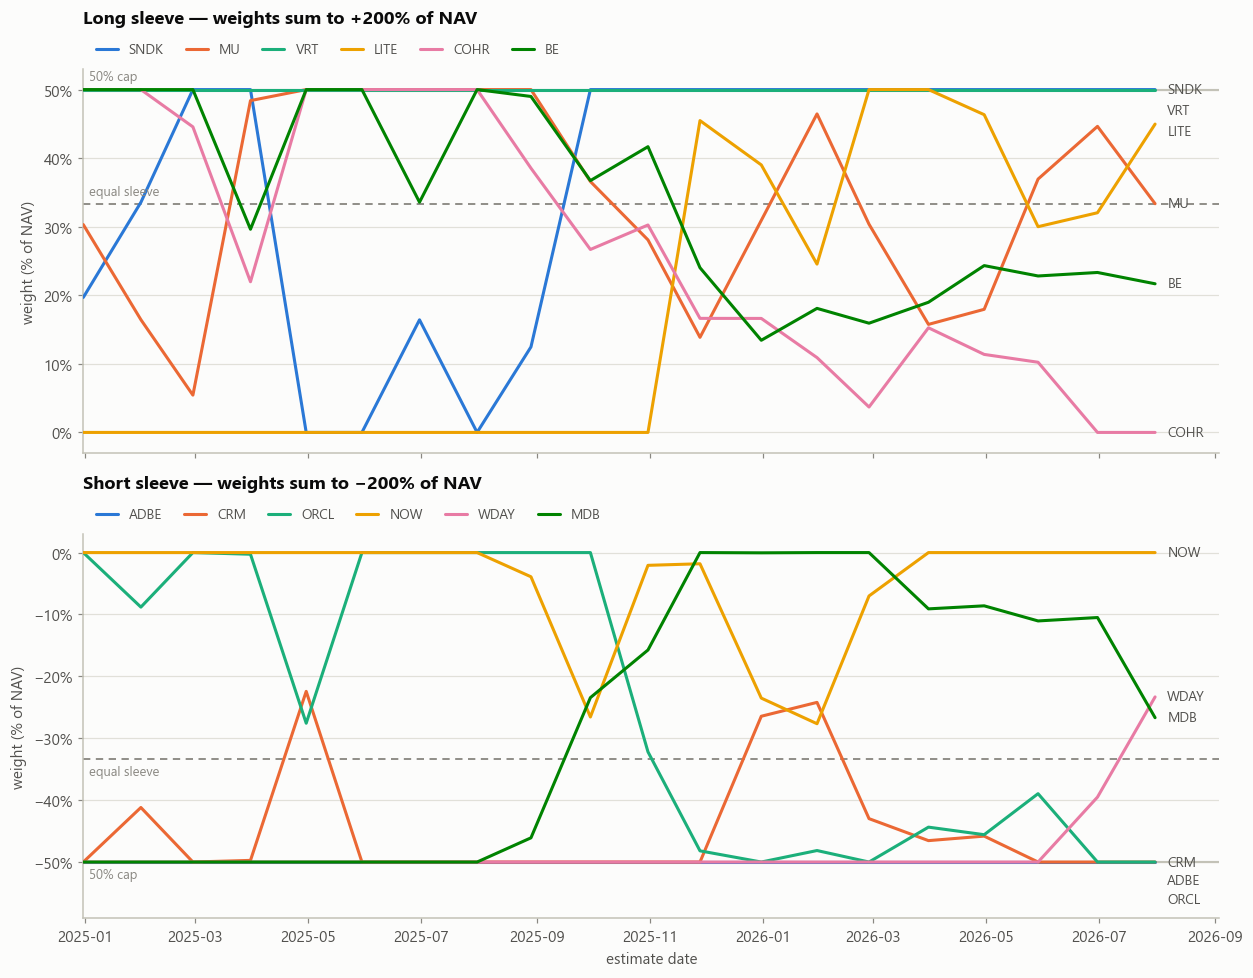

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 9), sharex=True)

for ax, sleeve, title, sign in (
    (axes[0], panel.longs,  "Long sleeve — weights sum to +200% of NAV",  +1),
    (axes[1], panel.shorts, "Short sleeve — weights sum to −200% of NAV", -1),
):
    frame = W[sleeve]
    for i, t in enumerate(sleeve):
        ax.plot(frame.index, frame[t], color=SERIES[i], lw=2, label=t, zorder=3)
    ax.axhline(sign * 2 / len(sleeve), color=MUTED, ls=(0, (4, 3)), lw=1.2, zorder=2)
    ax.axhline(sign * POSITION_CAP, color=AXIS, lw=1.4, zorder=2)
    ax.annotate("equal sleeve", xy=(frame.index[0], sign * 2 / len(sleeve)),
                xytext=(4, 4 * sign), textcoords="offset points",
                fontsize=8.5, color=MUTED, va="bottom" if sign > 0 else "top")
    ax.annotate("50% cap", xy=(frame.index[0], sign * POSITION_CAP),
                xytext=(4, 4 * sign), textcoords="offset points",
                fontsize=8.5, color=MUTED, va="bottom" if sign > 0 else "top")
    style(ax, title=title, ylabel="weight (% of NAV)", pct=0)
    ax.title.set_position((0, 1.0))
    ax.set_title(title, loc="left", fontsize=12, fontweight="bold", pad=30)
    span = frame.index[-1] - frame.index[0]
    ax.set_xlim(frame.index[0], frame.index[-1] + span * 0.06)   # room for end labels
    label_ends(ax, frame)
    ax.legend(ncol=6, loc="lower left", bbox_to_anchor=(0, 1.0), fontsize=9,
              handlelength=1.6, columnspacing=1.6, labelcolor=INK2)

axes[1].set_xlabel("estimate date")
plt.tight_layout()
plt.show()

Twenty estimate dates run from December 31, 2024 through July 31, 2026, of which
nineteen are held over a following month; the July 31, 2026 vector is the
allocation decision of Section 6.2 and is never held.

**Every vector satisfies the mandate.** The solver reports success at all twenty
dates, and all seven checks hold at all twenty: no sleeve sum drifts, no sign
flips, and the largest absolute weight anywhere in the panel is exactly 0.500000 —
the cap is reached but never breached.

The plot shows what the cap does to the rule. **It binds at 114 of the 240
stock-dates, 47.5% of all positions**, and the weight paths are close to
bang-bang: names sit at 0% or at the cap and travel between them quickly, with few
stable interior values. VRT holds 50% at every single estimate date; ADBE holds
−50% at every one. This follows from the arithmetic noted in 3.2 — with six names
per sleeve, a ±2 sum, and a 0.50 cap, at least four names must carry weight and at
most four can be capped — so each month the optimizer is really choosing which four
names to cap and how to divide the remainder. Small changes in the estimated
ranking therefore produce large, discontinuous changes in weights, which is exactly
what Section 4.2 measures.

## 4.2 Weight ranges, turnover, and the two largest month-to-month moves

In [32]:
weight_range = pd.DataFrame({
    "side": panel.descriptions["side"].reindex(panel.stocks),
    "equal sleeve": w_eq,
    "min weight": W.min(),
    "max weight": W.max(),
    "range": W.max() - W.min(),
    "mean weight": W.mean(),
    "hits 50% cap": (W.abs() >= POSITION_CAP - 1e-9).any(),
    "hits zero": (W.abs() <= 1e-9).any(),
}).loc[panel.stocks]
show(weight_range, title="Minimum and maximum weight at any estimate date")

Minimum and maximum weight at any estimate date


,side,equal sleeve,min weight,max weight,range,mean weight,hits 50% cap,hits zero
SNDK,long,0.3333,0.0000,0.5000,0.5000,0.3661,True,True
MU,long,0.3333,0.0544,0.5000,0.4456,0.3428,True,False
VRT,long,0.3333,0.5000,0.5000,0.0000,0.5000,True,False
LITE,long,0.3333,0.0000,0.5000,0.5000,0.1812,True,True
COHR,long,0.3333,0.0000,0.5000,0.5000,0.2734,True,True
BE,long,0.3333,0.1344,0.5000,0.3656,0.3366,True,False
ADBE,short,-0.3333,-0.5000,-0.5000,0.0000,-0.5000,True,False
CRM,short,-0.3333,-0.5000,-0.2243,0.2757,-0.4497,True,False
ORCL,short,-0.3333,-0.5000,0.0000,0.5000,-0.2470,True,True
NOW,short,-0.3333,-0.2765,0.0000,0.2765,-0.0463,False,True


In [33]:
targets_eq = equal_sleeve_targets(panel, dates)

bt_opt = backtest(panel, W,          TEST_START, TEST_END, NAV0)
bt_eq  = backtest(panel, targets_eq, TEST_START, TEST_END, NAV0)

to_opt = turnover(bt_opt, ANNUALIZATION, exclude=[LAST_ESTIMATE])
to_eq  = turnover(bt_eq,  ANNUALIZATION, exclude=[LAST_ESTIMATE])

turn = pd.DataFrame({
    "optimized": {
        "rebalances in test": to_opt["n rebalances"],
        "total one-way turnover": to_opt["total one-way"],
        "mean per rebalance": to_opt["per rebalance"].mean(),
        "max at one rebalance": to_opt["per rebalance"].max(),
        "annualized one-way turnover": to_opt["annualized one-way"],
    },
    "equal sleeve": {
        "rebalances in test": to_eq["n rebalances"],
        "total one-way turnover": to_eq["total one-way"],
        "mean per rebalance": to_eq["per rebalance"].mean(),
        "max at one rebalance": to_eq["per rebalance"].max(),
        "annualized one-way turnover": to_eq["annualized one-way"],
    },
})
display(turn)
print(f"\nTest window: {to_opt['years']:.2f} years "
      f"({len(bt_opt['returns'])} trading days)")
print(f"Criterion 1 threshold: {MAX_TURNOVER:.2%} of NAV per year "
      f"(1.5x the {cal_to['annualized one-way']:.2%} of the 2024 run)")
print(f"Optimized annualized one-way turnover: {to_opt['annualized one-way']:.2%} of NAV per year")
print(f"  = {to_opt['annualized one-way'] / cal_to['annualized one-way']:.2f}x the 2024 run, "
      f"{to_opt['annualized one-way'] / 4:.2f}x gross per year")
print(f"Equal sleeves re-estimate nothing, so its target never moves: "
      f"{to_eq['annualized one-way']:.2%} of NAV per year")

,optimized,equal sleeve
rebalances in test,18.0000,18.0000
total one-way turnover,6.0156,0.0000
mean per rebalance,0.3342,0.0000
max at one rebalance,0.7731,0.0000
annualized one-way turnover,3.8378,0.0000



Test window: 1.57 years (395 trading days)
Criterion 1 threshold: 515.64% of NAV per year (1.5x the 343.76% of the 2024 run)
Optimized annualized one-way turnover: 383.78% of NAV per year
  = 1.12x the 2024 run, 0.96x gross per year
Equal sleeves re-estimate nothing, so its target never moves: 0.00% of NAV per year


In [34]:
dW = W.diff().dropna(how="all")
move = dW.abs().sum(axis=1)          # L1 size of the change in the weight vector
ranked = move.sort_values(ascending=False)
print("Month-to-month change in the weight vector, L1 norm (sum of |Δw|)")
display(ranked.head(5).to_frame("L1 change").join(
    (ranked.head(5) / 2).to_frame("one-way, % of NAV")))
top2_moves = list(ranked.head(2).index)

Month-to-month change in the weight vector, L1 norm (sum of |Δw|)


,L1 change,"one-way, % of NAV"
estimate date,,
2025-04-30,1.5461,0.7731
2025-11-28,1.2294,0.6147
2025-09-30,1.2037,0.6018
2026-02-27,0.9219,0.4610
2025-03-31,0.8644,0.4322


In [35]:
def trace_move(d):
    """Show the weight change at date `d` alongside the change in its estimates."""
    prev = W.index[W.index.get_loc(d) - 1]
    mu_a, cov_a = inputs[prev]
    mu_b, cov_b = inputs[d]
    vol_a = pd.Series(np.sqrt(np.diag(cov_a.to_numpy())), index=cov_a.index)
    vol_b = pd.Series(np.sqrt(np.diag(cov_b.to_numpy())), index=cov_b.index)
    corr_a = cov_a.div(vol_a, axis=0).div(vol_a, axis=1)
    corr_b = cov_b.div(vol_b, axis=0).div(vol_b, axis=1)

    avg_corr = {}
    for sleeve in (panel.longs, panel.shorts):
        for t in sleeve:
            avg_corr[t] = (corr_b.loc[t, sleeve].drop(t).mean()
                           - corr_a.loc[t, sleeve].drop(t).mean())

    out = pd.DataFrame({
        "side": panel.descriptions["side"].reindex(panel.stocks),
        f"w {prev:%Y-%m-%d}": W.loc[prev],
        f"w {d:%Y-%m-%d}": W.loc[d],
        "Δ weight": W.loc[d] - W.loc[prev],
        "Δ ann. mean": (mu_b - mu_a).reindex(panel.stocks),
        "Δ ann. vol": (vol_b - vol_a).reindex(panel.stocks),
        "Δ Sharpe": (mu_b / vol_b - mu_a / vol_a).reindex(panel.stocks),
        "Δ avg corr. in sleeve": pd.Series(avg_corr).reindex(panel.stocks),
    }).loc[panel.stocks]

    entered = rets.loc[:d].iloc[-WINDOW:].index.difference(rets.loc[:prev].iloc[-WINDOW:].index)
    left    = rets.loc[:prev].iloc[-WINDOW:].index.difference(rets.loc[:d].iloc[-WINDOW:].index)
    print(f"\n=== {prev:%Y-%m-%d} -> {d:%Y-%m-%d} | one-way move "
          f"{move[d]/2:.2%} of NAV ===")
    print(f"window rolled: {len(entered)} days entered "
          f"({entered[0]:%Y-%m-%d}..{entered[-1]:%Y-%m-%d}), "
          f"{len(left)} days left ({left[0]:%Y-%m-%d}..{left[-1]:%Y-%m-%d})")
    show(out, pct=["Δ ann. mean", "Δ ann. vol"])
    return out

traces = {d: trace_move(d) for d in top2_moves}


=== 2025-03-31 -> 2025-04-30 | one-way move 77.31% of NAV ===
window rolled: 21 days entered (2025-04-01..2025-04-30), 21 days left (2022-03-25..2022-04-25)


,side,w 2025-03-31,w 2025-04-30,Δ weight,Δ ann. mean,Δ ann. vol,Δ Sharpe,Δ avg corr. in sleeve
SNDK,long,0.5000,0.0000,-0.5000,-11.00%,4.92%,-0.2724,0.0423
MU,long,0.4839,0.5000,0.0161,1.17%,3.35%,0.0018,0.0412
VRT,long,0.5000,0.5000,0.0000,8.56%,1.59%,0.1022,0.0346
LITE,long,0.0000,0.0000,0.0000,4.25%,3.36%,0.0802,0.0391
COHR,long,0.2198,0.5000,0.2802,6.69%,3.52%,0.0930,0.0376
BE,long,0.2963,0.5000,0.2037,5.88%,0.31%,0.0722,0.0146
ADBE,short,-0.5000,-0.5000,-0.0000,0.76%,0.20%,0.0197,0.0083
CRM,short,-0.4973,-0.2243,0.2731,7.05%,0.45%,0.1833,0.0135
ORCL,short,-0.0027,-0.2757,-0.2731,2.89%,1.43%,0.0526,0.0308
NOW,short,-0.0000,-0.0000,-0.0000,13.62%,1.68%,0.3066,0.0114



=== 2025-10-31 -> 2025-11-28 | one-way move 61.47% of NAV ===
window rolled: 19 days entered (2025-11-03..2025-11-28), 19 days left (2022-10-27..2022-11-22)


,side,w 2025-10-31,w 2025-11-28,Δ weight,Δ ann. mean,Δ ann. vol,Δ Sharpe,Δ avg corr. in sleeve
SNDK,long,0.5000,0.5000,-0.0000,4.94%,3.49%,-0.0065,0.0064
MU,long,0.2808,0.1387,-0.1421,0.43%,0.88%,-0.0122,0.0098
VRT,long,0.5000,0.5000,-0.0000,-0.22%,0.44%,-0.0163,0.0064
LITE,long,0.0000,0.4548,0.4548,27.22%,3.23%,0.4095,0.0195
COHR,long,0.3025,0.1663,-0.1362,5.89%,0.59%,0.0818,-0.0014
BE,long,0.4167,0.2402,-0.1765,-10.31%,1.18%,-0.1400,0.0173
ADBE,short,-0.5000,-0.5000,-0.0000,-3.41%,-0.94%,-0.0957,-0.0186
CRM,short,-0.5000,-0.5000,0.0000,-2.04%,-0.83%,-0.0447,-0.0184
ORCL,short,-0.3220,-0.4819,-0.1599,-11.62%,0.58%,-0.2882,-0.0016
NOW,short,-0.0206,-0.0181,0.0025,-7.75%,-1.96%,-0.1635,-0.0061


**Weight ranges.** Two names never move at all: VRT holds 50% and ADBE holds −50%
at all twenty dates, a range of exactly zero. At the other extreme SNDK, LITE,
COHR, ORCL, and MDB each traverse the entire feasible range, from 0% to the cap.
NOW is the one name that never reaches the cap: it ranges from −27.65% to 0% and
averages just −4.63%, spending most of the test at zero — the December 2024
judgment in 3.2 turns out to be a persistent one.

**Turnover.** Annualized one-way turnover is **383.78% of NAV per year** — 0.96
times gross exposure per year, an average holding period of about twelve and a half
months, and 1.12 times what the identical rule cost over 2024. Equal sleeves
registers exactly zero, because its target vector never changes and re-estimation
costs it nothing. That asymmetry is the entire trading-cost case against the
optimizer, and at these volatilities it is a small one: at 10bp one-way, 384% of
annual turnover is about 0.4% of NAV a year against a book running near 150%
annualized volatility.

**The two largest month-to-month moves.**

*March 31 to April 30, 2025 — 77.31% of NAV traded, the largest of the test.* SNDK
goes from the cap to zero, a 50-point swing, while COHR (+28.02) and BE (+20.37)
take its place; in the short sleeve CRM (+27.31) is swapped for ORCL (−27.31). The
estimates account for it directly. Twenty-one days of April 2025 entered the window
and twenty-one days of spring 2022 left it, and over that roll SNDK's estimated
annual mean fell 11.00 points while its volatility rose 4.92, cutting its estimated
Sharpe by **0.2724 — the largest deterioration in the long sleeve**. COHR's mean
gained 6.69 points and BE's 5.88 over the same roll, so the top-three ranking that
the cap rewards was reshuffled and the weights followed discontinuously. On the
short side CRM's Sharpe rose 0.1833, the second-largest increase in its sleeve,
making it a worse short and pushing it out of the capped group in favour of ORCL.

*October 31 to November 28, 2025 — 61.47% of NAV traded.* This one is essentially a
single name. **LITE goes from zero to 45.48%**, on the back of a 27.22-point jump
in its estimated annual mean and a **0.4095 rise in its estimated Sharpe, by far
the largest change of any name in the window**. It is funded by cutting BE by 17.65
points — following a 10.31-point *fall* in BE's estimated mean and a −0.1400 Sharpe
change — along with MU (−14.21) and COHR (−13.62). Nineteen days of November 2025
replaced nineteen days of late 2022, and that one month of new data was enough to
move a single position by 45 points of NAV. This is the window-chasing that a
rolling 756-day sample mean invites, and the cap converts it into an all-or-nothing
trade rather than a marginal tilt.

---
# 5 After 2024

## 5.1 Equal sleeves versus the optimizer, January 2, 2025 to July 31, 2026

In [36]:
perf = pd.DataFrame({
    "equal sleeve": performance_table(bt_eq["returns"]),
    "optimized": performance_table(bt_opt["returns"]),
})
display(perf)

print(f"\nfinal NAV, equal sleeve : ${bt_eq['nav'].iloc[-1]:,.0f}")
print(f"final NAV, optimized    : ${bt_opt['nav'].iloc[-1]:,.0f}")
print(f"difference              : ${bt_opt['nav'].iloc[-1] - bt_eq['nav'].iloc[-1]:,.0f}")

,equal sleeve,optimized
cumulative return,37.1283,25.7576
ann. mean,3.4584,3.3245
ann. volatility,1.4835,1.5372
Sharpe ratio,2.3313,2.1627
max drawdown,-0.8230,-0.8168
max drawdown date,2026-07-29 00:00:00,2026-07-29 00:00:00
worst day,-0.3596,-0.4525
worst day date,2025-01-27 00:00:00,2025-01-27 00:00:00



final NAV, equal sleeve : $3,812,829,190
final NAV, optimized    : $2,675,762,359
difference              : $-1,137,066,831


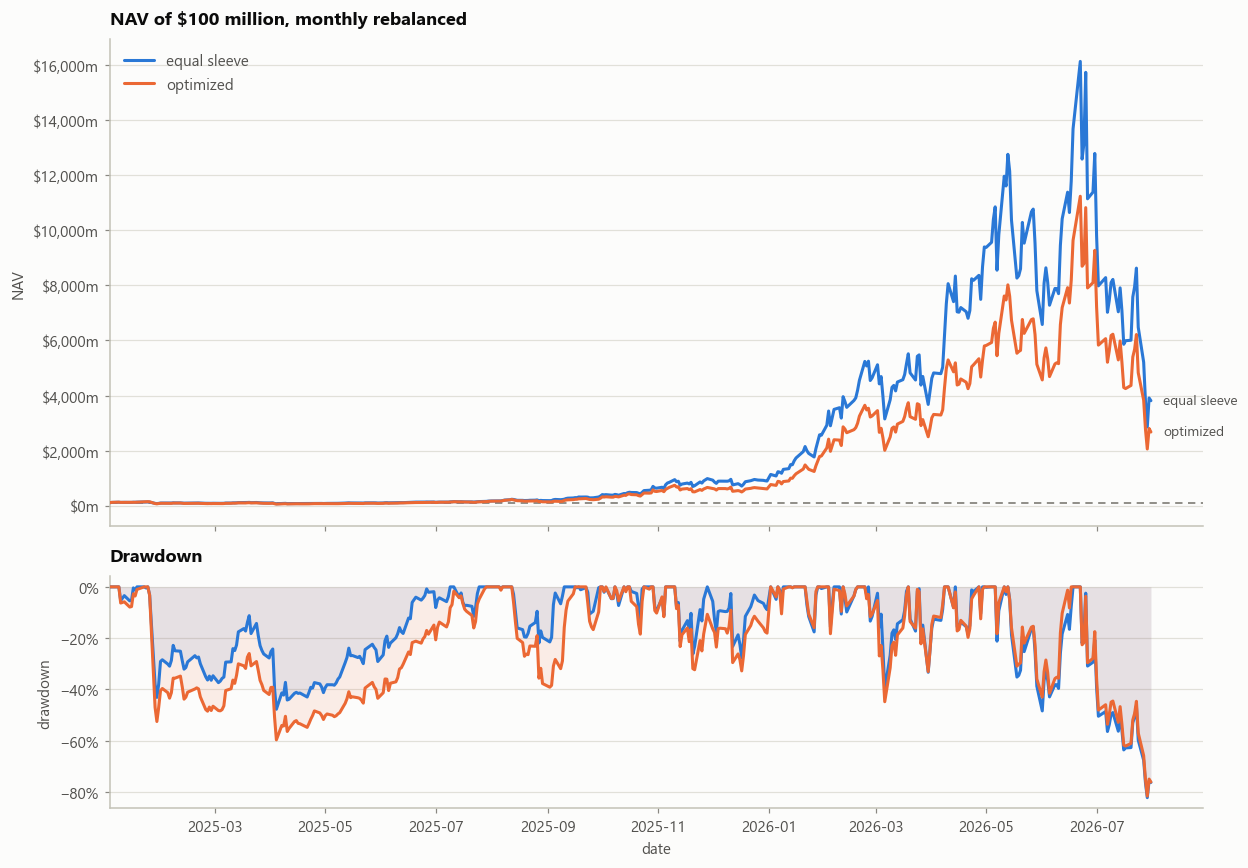

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2.1, 1]})

nav = pd.DataFrame({"equal sleeve": bt_eq["nav"], "optimized": bt_opt["nav"]})
colors = {"equal sleeve": SERIES[0], "optimized": SERIES[1]}

ax = axes[0]
for name in nav.columns:
    ax.plot(nav.index, nav[name], color=colors[name], lw=2, label=name, zorder=3)
ax.axhline(NAV0, color=MUTED, ls=(0, (4, 3)), lw=1.2, zorder=2)
style(ax, title="NAV of $100 million, monthly rebalanced", ylabel="NAV")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1e6:,.0f}m"))
ax.legend(loc="upper left", labelcolor=INK2)
span = nav.index[-1] - nav.index[0]
ax.set_xlim(nav.index[0], nav.index[-1] + span * 0.05)
label_ends(ax, nav)

ax = axes[1]
dd = pd.DataFrame({name: drawdown_path(bt["returns"])
                   for name, bt in (("equal sleeve", bt_eq), ("optimized", bt_opt))})
for name in dd.columns:
    ax.plot(dd.index, dd[name], color=colors[name], lw=2, zorder=3)
    ax.fill_between(dd.index, dd[name], 0, color=colors[name], alpha=0.10, lw=0, zorder=1)
style(ax, title="Drawdown", ylabel="drawdown", pct=0)
ax.set_xlabel("date")
ax.set_xlim(*axes[0].get_xlim())

plt.tight_layout()
plt.show()

Over the nineteen months from January 2, 2025 to July 31, 2026, **equal sleeves
beat the optimizer, and not narrowly.**

| | equal sleeve | optimized |
|---|---|---|
| cumulative return | **+3,712.83%** | +2,575.76% |
| annualized mean | 345.84% | 332.45% |
| annualized volatility | 148.35% | 153.72% |
| Sharpe ratio | **2.3313** | 2.1627 |
| maximum drawdown | −82.30% | −81.68% |
| worst day | −35.96% | −45.25% |

$100 million compounds to **$3.81 billion** under equal sleeves against **$2.68
billion** under the optimizer, a gap of $1.14 billion. The optimizer lost on both
halves of the ratio at once: 13.4 points less annualized return while carrying 5.4
points more volatility, for a Sharpe ratio 0.169 lower. Both books reach their
deepest drawdown on the same day, July 29, 2026, and both take their worst single
day on January 27, 2025 — but the optimizer's worst day is 9.3 points worse, −45.25%
against −35.96%, which is the concentration of Section 4.1 showing up in the tail.

These are extraordinary numbers, and they deserve a caveat rather than a victory
lap. Over this window the long sleeve compounded +780.8% and the short sleeve fell
−22.8%; run at 400% gross, that produces annualized volatility near 150%. At that
level the arithmetic mean and the compound return diverge enormously, drawdowns
past 80% are routine rather than exceptional, and the standard error on a
nineteen-month Sharpe ratio is on the order of 0.8 — comfortably larger than the
0.169 gap between the two books. **The ranking of the two portfolios is the finding
here.** The levels are a property of the mandate's leverage and of a fictional panel
in a violent trend, and nothing in them should be read as an estimate of anything
repeatable.

### Aside: why the weight vector, and not the positions, is what is held

The mandate is a statement about exposure — 400% gross, 0% net — so the book has
to be marked back to its target weights to keep it. The alternative reading, in
which the positions are held and the weights drift with their own returns, does
not merely differ at the margin here: it is a different strategy, and the cell
below shows how different.

In [38]:
drift_eq = backtest(panel, targets_eq, TEST_START, TEST_END, NAV0, drift=True)
g = drift_eq["held_weights"].abs().sum(axis=1)
n = drift_eq["held_weights"].sum(axis=1)

print("Equal sleeves, positions held instead of weights:")
print(f"  gross exposure   : min {g.min():.2f}x  median {g.median():.2f}x  max {g.max():.2f}x"
      f"   (mandate: 4.00x)")
print(f"  net exposure     : min {n.min():+.2f}x  median {n.median():+.2f}x  max {n.max():+.2f}x"
      f"   (mandate: 0.00x)")
print(f"  days outside 400% gross by more than 0.5x : "
      f"{int((g - 4).abs().gt(0.5).sum())} of {len(g)}")
print(f"  lowest NAV reached : ${drift_eq['nav'].min():,.0f}")
print()
print(f"  Holding the weight vector instead: gross "
      f"{bt_eq['held_weights'].abs().sum(axis=1).max():.2f}x at every date, "
      f"net {bt_eq['held_weights'].sum(axis=1).abs().max():.0e}.")

Equal sleeves, positions held instead of weights:
  gross exposure   : min 1.99x  median 3.66x  max 45.21x   (mandate: 4.00x)
  net exposure     : min -6.75x  median +0.13x  max +14.11x   (mandate: 0.00x)
  days outside 400% gross by more than 0.5x : 218 of 395
  lowest NAV reached : $-982,389,966

  Holding the weight vector instead: gross 4.00x at every date, net 1e-16.


Holding positions instead of weights turns the mandate into a different strategy.
Gross exposure ranges from 1.99× to **45.21×** and sits more than half a turn away
from 400% on **218 of 395 days**; net exposure, which the mandate fixes at zero,
ranges from −6.75× to +14.11×; and NAV reaches **−$982 million**, which is to say
the fund is destroyed. The mechanism is the ordinary leverage spiral: a drifting
book's weights are position values divided by NAV, so when NAV falls the weights
mechanically rise, and the July 2026 reversal drives the ratio through the floor.

Holding the weight vector keeps gross at 4.00× on every date and net at 10⁻¹⁶. That
is the exposure the mandate specifies, so it is the convention used throughout.

## 5.2 Where the two paths separate

In [39]:
m_opt = (1 + bt_opt["returns"]).resample("ME").prod() - 1
m_eq  = (1 + bt_eq["returns"]).resample("ME").prod() - 1
monthly = pd.DataFrame({"equal sleeve": m_eq, "optimized": m_opt})
monthly["difference"] = monthly["optimized"] - monthly["equal sleeve"]
show(monthly, pct=list(monthly.columns), title="Monthly returns")

split_month = monthly["difference"].abs().idxmax()
print(f"\nlargest one-month separation: {split_month:%B %Y}  "
      f"({monthly.loc[split_month, 'difference']:+.2%})")

Monthly returns


,equal sleeve,optimized,difference
2025-01-31,-3.20%,-12.28%,-9.08%
2025-02-28,-8.72%,-11.48%,-2.76%
2025-03-31,10.62%,8.57%,-2.05%
2025-04-30,-18.72%,-16.84%,1.88%
2025-05-31,20.68%,17.18%,-3.51%
2025-06-30,38.48%,50.61%,12.13%
2025-07-31,28.02%,30.75%,2.73%
2025-08-31,9.70%,-13.07%,-22.77%
2025-09-30,88.16%,93.65%,5.49%
2025-10-31,81.17%,89.20%,8.02%



largest one-month separation: November 2025  (-26.14%)


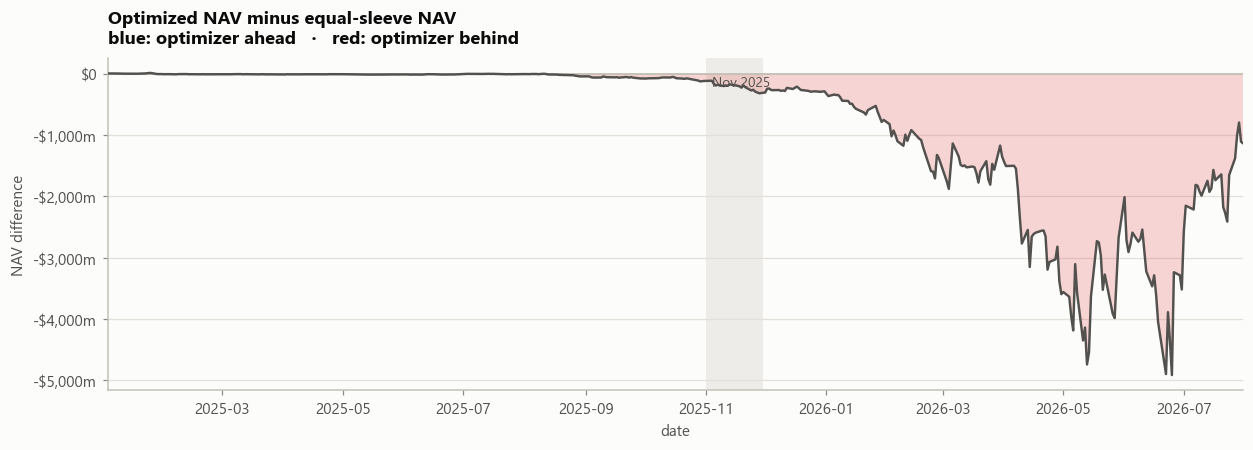

In [40]:
gap = (bt_opt["nav"] - bt_eq["nav"])

fig, ax = plt.subplots(figsize=(11.5, 4.2))
ax.plot(gap.index, gap, color=INK2, lw=1.6, zorder=4)
ax.fill_between(gap.index, gap, 0, where=gap >= 0, color=BLUE, alpha=0.22, lw=0, zorder=2)
ax.fill_between(gap.index, gap, 0, where=gap < 0,  color=RED,  alpha=0.22, lw=0, zorder=2)
ax.axhline(0, color=AXIS, lw=1.2, zorder=3)

lo = split_month.to_period("M").start_time
hi = split_month
ax.axvspan(lo, hi, color=GRID, alpha=0.55, lw=0, zorder=1)
ax.annotate(f"{split_month:%b %Y}", xy=(lo, ax.get_ylim()[1]), xytext=(4, -12),
            textcoords="offset points", fontsize=9, color=INK2, va="top")

style(ax, title="Optimized NAV minus equal-sleeve NAV\nblue: optimizer ahead   ·   red: optimizer behind",
      ylabel="NAV difference")
ax.yaxis.set_major_formatter(FuncFormatter(signed_millions))
ax.set_xlim(gap.index[0], gap.index[-1])
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

In [41]:
lo = max(bt_opt["returns"].index[0], split_month.to_period("M").start_time)
hi = split_month

a_opt = window_attribution(bt_opt, lo, hi, panel.longs, panel.shorts)
a_eq  = window_attribution(bt_eq,  lo, hi, panel.longs, panel.shorts)

held_opt = bt_opt["held_weights"].loc[lo:hi].iloc[0]
held_eq  = bt_eq["held_weights"].loc[lo:hi].iloc[0]
stock_ret = (1 + rets.loc[lo:hi]).prod() - 1

sep = pd.DataFrame({
    "side": panel.descriptions["side"].reindex(panel.stocks),
    "stock return": stock_ret.reindex(panel.stocks),
    "w equal sleeve": held_eq.reindex(panel.stocks),
    "w optimized": held_opt.reindex(panel.stocks),
    "Δ weight": (held_opt - held_eq).reindex(panel.stocks),
    "$ equal sleeve": a_eq["by stock"].reindex(panel.stocks),
    "$ optimized": a_opt["by stock"].reindex(panel.stocks),
    "$ difference": (a_opt["by stock"] - a_eq["by stock"]).reindex(panel.stocks),
}).loc[panel.stocks]
sep = sep.sort_values("$ difference")

show(sep, pct=["stock return"],
     money=["$ equal sleeve", "$ optimized", "$ difference"],
     title=f"{split_month:%B %Y}: attribution of the separation "
           f"({lo:%Y-%m-%d} to {hi:%Y-%m-%d})")

print(f"\nequal sleeve : {a_eq['return']:+.2%}   ${a_eq['pnl']:,.0f}")
print(f"optimized    : {a_opt['return']:+.2%}   ${a_opt['pnl']:,.0f}")
print(f"difference   : {a_opt['return'] - a_eq['return']:+.2%}   "
      f"${a_opt['pnl'] - a_eq['pnl']:,.0f}")
print(f"\nlong sleeve  : equal ${a_eq['long sleeve pnl']:,.0f}   "
      f"optimized ${a_opt['long sleeve pnl']:,.0f}")
print(f"short sleeve : equal ${a_eq['short sleeve pnl']:,.0f}   "
      f"optimized ${a_opt['short sleeve pnl']:,.0f}")

November 2025: attribution of the separation (2025-11-01 to 2025-11-30)


,side,stock return,w equal sleeve,w optimized,Δ weight,$ equal sleeve,$ optimized,$ difference
LITE,long,61.32%,0.3333,0.0000,-0.3333,"$123,470,065",$0,"$-123,470,065"
NOW,short,-11.63%,-0.3333,-0.0206,0.3127,"$31,121,022","$1,509,001","$-29,612,021"
COHR,long,24.48%,0.3333,0.3025,-0.0308,"$57,175,112","$36,769,080","$-20,406,032"
ORCL,short,-23.10%,-0.3333,-0.3220,0.0113,"$68,607,017","$51,014,803","$-17,592,214"
MDB,short,-7.63%,-0.3333,-0.1574,0.1759,"$19,770,011","$7,439,259","$-12,330,752"
VRT,long,-6.77%,0.3333,0.5000,0.1667,"$-20,340,990","$-27,957,383","$-7,616,393"
MU,long,5.68%,0.3333,0.2808,-0.0526,"$9,885,610","$5,184,873","$-4,700,737"
BE,long,-17.34%,0.3333,0.4167,0.0834,"$-50,587,528","$-53,159,824","$-2,572,295"
ADBE,short,-5.93%,-0.3333,-0.5000,-0.1667,"$14,636,277","$16,802,478","$2,166,201"
WDAY,short,-10.13%,-0.3333,-0.5000,-0.1667,"$27,268,354","$30,681,871","$3,413,517"



equal sleeve : +54.65%   $347,412,359
optimized    : +28.52%   $146,934,771
difference   : -26.14%   $-200,477,588

long sleeve  : equal $157,151,377   optimized $5,256,788
short sleeve : equal $190,260,982   optimized $141,677,982


In [42]:
# Was the tilt that drove the separation visible in the estimates beforehand?
est_date = max(d for d in W.index if d < lo)
mu_pre, cov_pre = inputs[est_date]
vol_pre = pd.Series(np.sqrt(np.diag(cov_pre.to_numpy())), index=cov_pre.index)

drivers = sep["$ difference"].abs().sort_values(ascending=False).head(3).index
foresight = pd.DataFrame({
    "side": panel.descriptions["side"].reindex(drivers),
    "Δ weight vs equal sleeve": (held_opt - held_eq).reindex(drivers),
    f"est. ann. mean at {est_date:%Y-%m-%d}": mu_pre.reindex(drivers),
    f"est. ann. vol at {est_date:%Y-%m-%d}": vol_pre.reindex(drivers),
    f"est. Sharpe at {est_date:%Y-%m-%d}": (mu_pre / vol_pre).reindex(drivers),
    f"realized return {lo:%b %d}–{hi:%b %d}": stock_ret.reindex(drivers),
    "$ difference": sep["$ difference"].reindex(drivers),
})
show(foresight,
     pct=[f"est. ann. mean at {est_date:%Y-%m-%d}", f"est. ann. vol at {est_date:%Y-%m-%d}",
          f"realized return {lo:%b %d}–{hi:%b %d}"],
     money=["$ difference"],
     title=f"The three largest drivers, against the estimates the optimizer actually saw "
           f"on {est_date:%Y-%m-%d}")

The three largest drivers, against the estimates the optimizer actually saw on 2025-10-31


,side,Δ weight vs equal sleeve,est. ann. mean at 2025-10-31,est. ann. vol at 2025-10-31,est. Sharpe at 2025-10-31,realized return Nov 01–Nov 30,$ difference
LITE,long,-0.3333,49.85%,56.27%,0.8860,61.32%,"$-123,470,065"
NOW,short,0.3127,37.57%,37.31%,1.0070,-11.63%,"$-29,612,021"
COHR,long,-0.0308,66.01%,64.05%,1.0306,24.48%,"$-20,406,032"


**The two paths separate most sharply in November 2025**, when equal sleeves
returned +54.65% against the optimizer's +28.52% — a 26.14-point gap worth $200.5
million.

Almost all of it is one position. The optimizer held **zero in LITE** that month
against equal sleeves' 33.33%, and **LITE returned +61.32%** in November. That
single missing long accounts for **$123.5 million of the $200.5 million
difference**, more than three-fifths of the total. The next two are the same kind of
thing: the optimizer had cut its NOW short to −2.06% against −33.33%, and NOW fell
11.63%, so the short it had abandoned would have made money (−$29.6 million of
relative performance); and it held slightly less COHR while COHR rose 24.48%
(−$20.4 million). Sleeve by sleeve, the long book is where it happened — equal
sleeves earned $157.2 million long against the optimizer's $5.3 million, while the
two short sleeves finished much closer, $190.3 million against $141.7 million.

**The optimizer was not punished for using its information badly. It was punished by
an outcome that information could not have anticipated.** On October 31, 2025 — the
date that set November's weights — LITE's trailing 756-day estimates showed an
annualized mean of 49.85%, volatility of 56.27%, and a Sharpe ratio of 0.8860. That
is a respectable but middling long, and with the cap forcing the sleeve into three
or four names, a middling long gets nothing. Nothing in the estimation window
flagged a 61% month.

The NOW decision was, if anything, the better-founded of the two on the evidence
available: NOW's trailing Sharpe of 1.0070 made it the least attractive short in
its sleeve, exactly the name a Sharpe-maximizer should refuse to short. It then fell
11.63%. Both decisions were defensible on the estimates and both were wrong in the
event, which is the distinction that matters for Section 6.2.

---
# 6 The Reversal and the Allocation

## 6.1 The July 24–29, 2026 reversal

In [43]:
rev_opt = window_attribution(bt_opt, REVERSAL_START, REVERSAL_END, panel.longs, panel.shorts)
rev_eq  = window_attribution(bt_eq,  REVERSAL_START, REVERSAL_END, panel.longs, panel.shorts)

print(f"reversal window: {rev_opt['dates'][0]:%Y-%m-%d} to {rev_opt['dates'][-1]:%Y-%m-%d} "
      f"({len(rev_opt['dates'])} trading days)")
print(f"weights in force were set at the {max(d for d in W.index if d < REVERSAL_START):%Y-%m-%d} close\n")

def _headline(a):
    return {
        "return": f"{a['return']:+.2%}",
        "P&L": f"${a['pnl']:,.0f}",
        "long sleeve P&L": f"${a['long sleeve pnl']:,.0f}",
        "short sleeve P&L": f"${a['short sleeve pnl']:,.0f}",
        "NAV before": f"${a['nav start']:,.0f}",
        "NAV after": f"${a['nav end']:,.0f}",
    }

display(pd.DataFrame({"equal sleeve": _headline(rev_eq),
                      "optimized": _headline(rev_opt)}))

reversal window: 2026-07-24 to 2026-07-29 (4 trading days)


weights in force were set at the 2026-06-30 close



,equal sleeve,optimized
return,-66.91%,-66.89%
P&L,"$-5,771,752,104","$-4,157,113,780"
long sleeve P&L,"$-3,791,892,034","$-2,767,831,252"
short sleeve P&L,"$-1,979,860,070","$-1,389,282,527"
NAV before,"$8,626,725,626","$6,215,216,533"
NAV after,"$2,854,973,522","$2,058,102,754"


In [44]:
rev_stock_ret = (1 + rets.loc[REVERSAL_START:REVERSAL_END]).prod() - 1
rev_w_opt = bt_opt["held_weights"].loc[REVERSAL_START:REVERSAL_END].iloc[0]
rev_w_eq  = bt_eq["held_weights"].loc[REVERSAL_START:REVERSAL_END].iloc[0]

rev = pd.DataFrame({
    "side": panel.descriptions["side"].reindex(panel.stocks),
    "stock return": rev_stock_ret.reindex(panel.stocks),
    "w equal sleeve": rev_w_eq.reindex(panel.stocks),
    "w optimized": rev_w_opt.reindex(panel.stocks),
    "$ equal sleeve": rev_eq["by stock"].reindex(panel.stocks),
    "$ optimized": rev_opt["by stock"].reindex(panel.stocks),
    "$ difference": (rev_opt["by stock"] - rev_eq["by stock"]).reindex(panel.stocks),
}).loc[panel.stocks]

show(rev, pct=["stock return"],
     money=["$ equal sleeve", "$ optimized", "$ difference"],
     title="Reversal attribution by stock")

print("\nThree largest stock contributions")
for label, attr in (("equal sleeve", rev_eq), ("optimized", rev_opt)):
    top3 = attr["by stock"].abs().sort_values(ascending=False).head(3).index
    total = attr["pnl"]
    print(f"  {label}:")
    for t in top3:
        v = attr["by stock"][t]
        print(f"    {t:5s} ${v:>14,.0f}   {v/total:>7.1%} of the window's P&L")

Reversal attribution by stock


,side,stock return,w equal sleeve,w optimized,$ equal sleeve,$ optimized,$ difference
SNDK,long,-36.91%,0.3333,0.5000,"$-888,108,523","$-975,762,320","$-87,653,797"
MU,long,-25.37%,0.3333,0.4463,"$-528,818,918","$-516,935,966","$11,882,952"
VRT,long,-26.64%,0.3333,0.5000,"$-476,490,479","$-522,334,298","$-45,843,819"
LITE,long,-27.74%,0.3333,0.3204,"$-630,506,185","$-443,291,526","$187,214,658"
COHR,long,-29.11%,0.3333,0.0000,"$-657,190,860",$0,"$657,190,860"
BE,long,-24.64%,0.3333,0.2333,"$-610,777,069","$-309,507,141","$301,269,928"
ADBE,short,24.16%,-0.3333,-0.5000,"$-452,270,984","$-496,473,112","$-44,202,128"
CRM,short,20.04%,-0.3333,-0.5000,"$-381,340,761","$-419,611,497","$-38,270,736"
ORCL,short,-1.92%,-0.3333,-0.5000,"$51,218,154","$52,387,393","$1,169,239"
NOW,short,25.91%,-0.3333,0.0000,"$-504,029,203",$0,"$504,029,203"



Three largest stock contributions
  equal sleeve:
    SNDK  $  -888,108,523     15.4% of the window's P&L
    COHR  $  -657,190,860     11.4% of the window's P&L
    LITE  $  -630,506,185     10.9% of the window's P&L
  optimized:
    SNDK  $  -975,762,320     23.5% of the window's P&L
    VRT   $  -522,334,298     12.6% of the window's P&L
    MU    $  -516,935,966     12.4% of the window's P&L


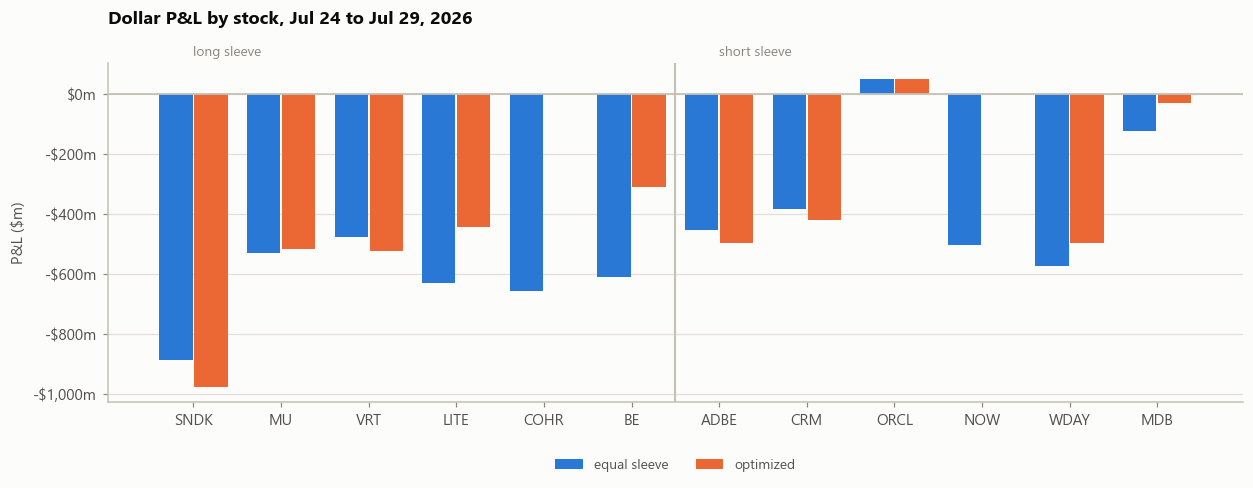

In [45]:
fig, ax = plt.subplots(figsize=(11.5, 4.6))
x = np.arange(len(panel.stocks))
w = 0.38
pad = 0.02                                    # 2px-equivalent surface gap between bars

ax.bar(x - w/2 - pad/2, rev["$ equal sleeve"] / 1e6, w, color=SERIES[0],
       label="equal sleeve", zorder=3)
ax.bar(x + w/2 + pad/2, rev["$ optimized"] / 1e6, w, color=SERIES[1],
       label="optimized", zorder=3)
ax.axhline(0, color=AXIS, lw=1.2, zorder=4)
ax.axvline(len(panel.longs) - 0.5, color=AXIS, lw=1.4, zorder=1)

# Sleeve labels sit above the plot area so they never land on a bar.
trans = mpl.transforms.blended_transform_factory(ax.transData, ax.transAxes)
ax.text(0, 1.015, "long sleeve", transform=trans, fontsize=9, color=MUTED, va="bottom")
ax.text(len(panel.longs), 1.015, "short sleeve", transform=trans,
        fontsize=9, color=MUTED, va="bottom")

ax.set_xticks(x, panel.stocks)
style(ax, title=f"Dollar P&L by stock, {REVERSAL_START:%b %d} to {REVERSAL_END:%b %d, %Y}",
      ylabel="P&L ($m)")
ax.set_title(f"Dollar P&L by stock, {REVERSAL_START:%b %d} to {REVERSAL_END:%b %d, %Y}",
             loc="left", fontsize=12, fontweight="bold", pad=26)
ax.yaxis.set_major_formatter(FuncFormatter(
    lambda v, _: "$0m" if abs(v) < 1e-9 else f"{'+' if v > 0 else '-'}${abs(v):,.0f}m"))
ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.13),
          bbox_transform=ax.transAxes, fontsize=9, labelcolor=INK2)
plt.tight_layout()
plt.show()

Over the four trading days from July 24 to July 29, 2026, both books lost roughly
two-thirds of their value, in almost exactly the same proportion.

| | equal sleeve | optimized |
|---|---|---|
| return | −66.91% | −66.89% |
| P&L | −$5.772bn | −$4.157bn |
| long sleeve | −$3.792bn | −$2.768bn |
| short sleeve | −$1.980bn | −$1.389bn |
| NAV before → after | $8.63bn → $2.85bn | $6.22bn → $2.06bn |

The dollar figures differ only because the optimizer arrived at July 24 with a
smaller NAV. In return terms the two are indistinguishable — two basis points apart.

**Both sleeves lost, which is the defining feature of this reversal.** The long
sleeve fell hard — SNDK −36.91%, COHR −29.11%, LITE −27.74%, VRT −26.64%, MU
−25.37%, BE −24.64% — and the short sleeve rallied into it: WDAY +31.39%, NOW
+25.91%, ADBE +24.16%, CRM +20.04%. A 400% gross book that is long one theme and
short its complement has no defence when the two legs converge; the hedge and the
position moved against the book together. ORCL, at −1.92%, was the only one of the
twelve that did not hurt.

Three largest stock contributions, equal sleeves: **SNDK −$888.1m (15.4% of the
loss), COHR −$657.2m (11.4%), LITE −$630.5m (10.9%)**. Optimized: **SNDK −$975.8m
(23.5%), VRT −$522.3m (12.6%), MU −$516.9m (12.4%)**.

**Which earlier weight decisions mattered most.** The June 30, 2026 vector carried
two large protective bets and several costly ones, and they very nearly cancelled.
Zeroing COHR saved **$657.2 million** against equal sleeves, and zeroing the NOW
short saved **$504.0 million** — the two best decisions in the book, and both were
decisions to hold *nothing*. Against them, capping SNDK at 50% instead of 33.33%
cost **$87.7 million**, and capping the ADBE and CRM shorts at −50% cost $44.2
million and $38.3 million as those names rallied. Net effect on the return: two
basis points.

The lasting point is about concentration rather than direction. Equal sleeves spread
its worst week across three names contributing 15.4%, 11.4%, and 10.9% of the loss.
The optimizer's cap-driven concentration put **23.5% of its entire loss into SNDK
alone**. In a week when every position moved the same way, holding fewer and larger
positions bought no protection and made the outcome depend far more on one name.

## 6.2 Applying the criteria and choosing the allocation

In [46]:
turnover_opt = to_opt["annualized one-way"]
mandate_ok = bool(all_checks.all().all()) and bool(roll_diag["solver success"].all())

sharpe_gain = perf.loc["Sharpe ratio", "optimized"] - perf.loc["Sharpe ratio", "equal sleeve"]
dd_worsening = perf.loc["max drawdown", "equal sleeve"] - perf.loc["max drawdown", "optimized"]

turnover_ratio = turnover_opt / cal_to["annualized one-way"]
c1a = turnover_opt <= MAX_TURNOVER
c1b = mandate_ok
c2a = sharpe_gain >= MIN_SHARPE_GAIN
c2b = dd_worsening <= MAX_DD_WORSENING

c1 = bool(c1a and c1b)
c2 = bool(c2a and c2b)

verdict = pd.DataFrame([
    {"criterion": "1 — turnover",
     "threshold": f"<= 1.5x the 2024 run ({MAX_TURNOVER:.0%} / yr)",
     "realized": f"{turnover_opt:.0%} / yr = {turnover_ratio:.2f}x the 2024 run",
     "pass": bool(c1a)},
    {"criterion": "1 — mandate", "threshold": "no violation at any month-end",
     "realized": "no violations" if mandate_ok else "violations found", "pass": bool(c1b)},
    {"criterion": "2 — Sharpe", "threshold": f">= {MIN_SHARPE_GAIN:+.2f}",
     "realized": f"{sharpe_gain:+.3f}", "pass": bool(c2a)},
    {"criterion": "2 — drawdown", "threshold": f"no more than {MAX_DD_WORSENING:.0%} deeper",
     "realized": f"{dd_worsening:+.2%} deeper", "pass": bool(c2b)},
]).set_index("criterion")
display(verdict)

print(f"\nCriterion 1 (weights / turnover) : {'PASS' if c1 else 'FAIL'}")
print(f"Criterion 2 (return / risk)      : {'PASS' if c2 else 'FAIL'}")
DECISION = "optimized" if (c1 and c2) else "equal sleeve"
print(f"\nBoth criteria must pass to replace equal sleeves.")
print(f"DECISION at the {LAST_ESTIMATE:%Y-%m-%d} close: {DECISION.upper()}")

,threshold,realized,pass
criterion,,,
1 — turnover,<= 1.5x the 2024 run (516% / yr),384% / yr = 1.12x the 2024 run,True
1 — mandate,no violation at any month-end,no violations,True
2 — Sharpe,>= +0.25,-0.169,False
2 — drawdown,no more than 5% deeper,-0.62% deeper,True



Criterion 1 (weights / turnover) : PASS
Criterion 2 (return / risk)      : FAIL

Both criteria must pass to replace equal sleeves.
DECISION at the 2026-07-31 close: EQUAL SLEEVE


In [47]:
w_final_opt = W.loc[LAST_ESTIMATE]
w_chosen = w_final_opt if DECISION == "optimized" else w_eq

final = pd.DataFrame({
    "name": panel.descriptions["name"].reindex(panel.stocks),
    "side": panel.descriptions["side"].reindex(panel.stocks),
    "equal sleeve": w_eq,
    f"optimized {LAST_ESTIMATE:%Y-%m-%d}": w_final_opt.reindex(panel.stocks),
    "CHOSEN weight": w_chosen.reindex(panel.stocks),
    "position on $100m NAV": w_chosen.reindex(panel.stocks) * NAV0,
}).loc[panel.stocks]
show(final, money=["position on $100m NAV"],
     title=f"Allocation carried into August 2026 — {DECISION}")

chosen_exp = exposure_summary(w_chosen, panel.longs, panel.shorts)
chosen_chk = mandate_checks(w_chosen, panel.longs, panel.shorts, RULE)
print("Exposures of the chosen allocation")
display(chosen_exp.to_frame("chosen"))
print("Mandate checks")
display(chosen_chk.to_frame("pass"))
print("chosen allocation satisfies the mandate:", bool(chosen_chk.all()))

Allocation carried into August 2026 — equal sleeve


,name,side,equal sleeve,optimized 2026-07-31,CHOSEN weight,position on $100m NAV
SNDK,Sandisk,long,0.3333,0.5000,0.3333,"$33,333,333"
MU,Micron Technology,long,0.3333,0.3336,0.3333,"$33,333,333"
VRT,Vertiv,long,0.3333,0.5000,0.3333,"$33,333,333"
LITE,Lumentum,long,0.3333,0.4497,0.3333,"$33,333,333"
COHR,Coherent,long,0.3333,0.0000,0.3333,"$33,333,333"
BE,Bloom Energy,long,0.3333,0.2168,0.3333,"$33,333,333"
ADBE,Adobe,short,-0.3333,-0.5000,-0.3333,"$-33,333,333"
CRM,Salesforce,short,-0.3333,-0.5000,-0.3333,"$-33,333,333"
ORCL,Oracle,short,-0.3333,-0.5000,-0.3333,"$-33,333,333"
NOW,ServiceNow,short,-0.3333,0.0000,-0.3333,"$-33,333,333"


Exposures of the chosen allocation


,chosen
long exposure,2.0000
short exposure,-2.0000
gross exposure,4.0000
net exposure,0.0000
largest |position|,0.3333
largest position name,SNDK


Mandate checks


,pass
long sum = +2,True
short sum = -2,True
gross = 400%,True
net = 0%,True
longs nonnegative,True
shorts nonpositive,True
|w| <= 50% cap,True


chosen allocation satisfies the mandate: True


In [48]:
# Did the trailing estimates rank the cross-section correctly over the test?

vol24 = pd.Series(np.sqrt(np.diag(cov24.to_numpy())), index=cov24.index)
trailing_sharpe = (mu24 / vol24).reindex(panel.stocks)
realized = ((1 + rets.loc[TEST_START:TEST_END]).prod() - 1).reindex(panel.stocks)

hindsight = pd.DataFrame({
    "side": panel.descriptions["side"].reindex(panel.stocks),
    "trailing Sharpe at 2024-12-31": trailing_sharpe,
    "mean optimized weight": W.mean().reindex(panel.stocks),
    "equal-sleeve weight": w_eq,
    "realized return 2025-26": realized,
}).loc[panel.stocks]
show(hindsight, pct=["realized return 2025-26"],
     title="What the estimates said, what the optimizer did, and what happened")

for sleeve, name in ((panel.longs, "long"), (panel.shorts, "short")):
    rho, pv = spearmanr(trailing_sharpe[sleeve], realized[sleeve])
    print(f"{name:5s} sleeve  Spearman(trailing Sharpe, realized test return) = "
          f"{rho:+.3f}  (p = {pv:.2f}, n = {len(sleeve)})")

What the estimates said, what the optimizer did, and what happened


,side,trailing Sharpe at 2024-12-31,mean optimized weight,equal-sleeve weight,realized return 2025-26
SNDK,long,0.1660,0.3661,0.3333,"2,678.86%"
MU,long,0.1691,0.3428,0.3333,881.81%
VRT,long,1.1328,0.5000,0.3333,113.02%
LITE,long,0.0800,0.1812,0.3333,750.43%
COHR,long,0.4788,0.2734,0.3333,177.52%
BE,long,0.3871,0.3366,0.3333,826.65%
ADBE,short,-0.0219,-0.5000,-0.3333,-43.69%
CRM,short,0.4320,-0.4497,-0.3333,-44.31%
ORCL,short,0.8822,-0.2470,-0.3333,-20.51%
NOW,short,0.5937,-0.0463,-0.3333,-47.54%


long  sleeve  Spearman(trailing Sharpe, realized test return) = -0.657  (p = 0.16, n = 6)
short sleeve  Spearman(trailing Sharpe, realized test return) = -0.371  (p = 0.47, n = 6)


**Criterion 1 passes. Criterion 2 fails. The mandate stays on equal sleeves.**

| criterion | threshold | realized | |
|---|---|---|---|
| 1 — turnover | ≤ 1.5× the 2024 run (516%/yr) | 384%/yr = 1.12× | PASS |
| 1 — mandate | no violation at any month-end | none in 20 dates | PASS |
| 2 — Sharpe | ≥ +0.25 | **−0.169** | **FAIL** |
| 2 — drawdown | no more than 5pp deeper | 0.62pp shallower | PASS |

The optimizer is a well-behaved rule. It traded 384% of NAV a year, only 12% more
than the identical rule cost over 2024, and it never once breached the cap or the
sleeve constraints across twenty estimate dates. Its drawdown came in marginally
*shallower* than equal sleeves'. On everything Criterion 1 and the risk leg of
Criterion 2 were built to detect, the position cap did its job: it produced a
stable, implementable, mandate-compliant portfolio out of inputs that Section 1.2
showed would otherwise have produced nonsense.

It simply did not earn anything. It needed to beat equal sleeves' Sharpe ratio by
0.25 and came in 0.169 *below* it — a miss of 0.42 against the hurdle, with the
wrong sign entirely.

**The allocation at the July 31, 2026 close is equal sleeves: +33.33% of NAV in
each of SNDK, MU, VRT, LITE, COHR, and BE, and −33.33% in each of ADBE, CRM, ORCL,
NOW, WDAY, and MDB — $33,333,333 per position on $100 million of NAV, 400% gross,
0% net.**

### Why it failed

This is worth separating from bad luck, because the mechanism is specific. The
optimizer's only source of edge is the trailing 756-day sample, and over this test
that sample ranked the cross-section backwards. Rank the six longs by their trailing
Sharpe ratio at December 31, 2024 and compare with what they actually returned over
the test window: the **Spearman rank correlation is −0.657**.

The three cases that carry it:

| | trailing Sharpe at 2024-12-31 | mean optimized weight | realized 2025–26 return |
|---|---|---|---|
| VRT | **1.1328** (best of the six) | 50.00% (capped at all 20 dates) | **+113%** (worst of the six) |
| LITE | **0.0800** (worst of the six) | 18.12% | **+750%** |
| SNDK | 0.1660 | 36.61% | **+2,679%** |

With six observations that correlation is not statistically significant (p = 0.16),
and it should not be read as evidence that trailing Sharpe predicts *negatively*.
What it does establish is that trailing Sharpe carried no usable information about
the next nineteen months here — and that the position cap, by design, converted a
non-signal into large, confident, and wrong positions. VRT is the clean example: the
single best-looking name in the portfolio on December 2024 estimates, pinned at the
maximum permitted weight at every one of twenty rebalances, delivering the worst
return of its sleeve.

### What would reverse the choice

Keep running both books on the identical schedule — same 756-day window, same
month-end re-estimation, same constant-weight convention — and track **the optimized
book's realized trailing-twelve-month Sharpe ratio minus the equal-sleeve book's**,
recomputed at each month-end from daily returns.

Switch to the optimized allocation if that difference is **at or above +0.25 at the
July 31, 2027 close, and has been positive at no fewer than six of the twelve
intervening month-ends.**

The second leg is the part that matters. A single month like November 2025 moves a
nineteen-month Sharpe comparison by more than the whole hurdle, so a threshold
tested on one date would mostly measure which month it landed on. Requiring
persistence is what separates a genuine change in the estimates' information content
from one lucky name. The underlying quantity driving any such improvement would be
the rank correlation computed above — trailing Sharpe beginning to order the
cross-section correctly rather than backwards — and it is worth tracking directly
alongside the Sharpe difference, since it is the mechanism rather than the symptom.

---